# Echo State Networks - Architecture Comparison on Increasingly Difficult Synthetic Signals

**Notebook 3** of a research series framed within Antonio Macías Ferrera's Master's thesis
(*General Study of the Reservoir Topology on Echo State Networks*, University of Seville).

This notebook extends the **Phase-B topology study** of Notebook 1 by evaluating three reservoir
architectures - Erdős-Rényi (ER), Watts-Strogatz (WS), and Barabási-Albert (BA) - across a
**progression of ten synthetic signals of increasing complexity**.

Each signal is strictly harder than Notebook 1's baseline by incorporating more periodic components and stronger noise.

For every (signal x architecture) pair we sweep the key structural parameter(s) under 5-fold
temporal cross-validation, identify the optimal topology configuration, and record the best RMSE.
A final **comparison grid** reveals how architecture sensitivity changes as signal difficulty grows.

| Signal | Frequencies | Noise sr | Extra difficulty |
|--------|-------------|---------|------------------|
| NB1 ref. | 3 | 0.05 | - (baseline) |
| **S1** | 4 | 0.12 | +1 incommensurate period (T=83) |
| **S2** | 5 | 0.22 | beating pair (T=50 & T=53, beat≈833 ts) |
| **S3** | 6 | 0.38 | slow amplitude modulation (T_AM=5 000) |
| **S4** | 7 | 0.56 | strong AM (T_AM=3 000) + dense multi-scale beating |
| **S5** | 8 | 0.70 | very strong AM (T_AM=2 000) + extra high-freq T=19 |
| **S6** | 9 | 0.85 | chaotic-like multi-scale beating (T_AM=1 500) |
| **S7** | 10 | 1.00 | double AM envelope (T_AM=2 500 & T_AM=700) |
| **S8** | 11 | 1.20 | triple beating clusters + double AM (T_AM=3 500 & T_AM=500) |
| **S9** | 12 | 1.50 | extreme noise + full non-stationarity (T_AM=4 000 & T_AM=400) |
| **S10** | 13 | 2.00 | maximum AM complexity (T_AM=5 000 & T_AM=300) |

## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Synthetic Signal Definitions](#2-synthetic-signal-definitions)
3. [ESN Configuration & Helper Functions](#3-esn-configuration--helper-functions)
4. [Topology Study - Signal S1](#4-topology-study---signal-s1)
5. [Topology Study - Signal S2](#5-topology-study---signal-s2)
6. [Topology Study - Signal S3](#6-topology-study---signal-s3)
7. [Topology Study - Signal S4](#7-topology-study---signal-s4)
8. [Cross-Signal Architecture Comparison Grid](#8-cross-signal-architecture-comparison-grid)
9. [Final Comparison — Mean RMSE vs. Signal Difficulty](#9-final-comparison--mean-rmse-vs-signal-difficulty)

## 1. Environment Setup

In [1]:
import time
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

print("Library versions")
for lib_name, lib in [("numpy", np), ("pandas", pd), ("reservoirpy", rpy),
                       ("networkx", nx), ("seaborn", sns)]:
    print(f"  {lib_name:15s} {lib.__version__}")


Library versions
  numpy           2.4.2
  pandas          3.0.1
  reservoirpy     0.4.1
  networkx        3.6.1
  seaborn         0.13.2


In [2]:
# ---------------------------------------------------------------------------
# Global configuration
# ---------------------------------------------------------------------------
N_SPLITS  = 10          # temporal CV folds
LAG       = 10          # look-back window (same as Notebook 1)
T         = 15_000      # signal length
SEED      = 42

os.makedirs("single_hp_outputs_3", exist_ok=True)

np.random.seed(SEED)
rpy.set_seed(SEED)

print(f"  CV folds    : {N_SPLITS}")
print(f"  Input lag   : {LAG}")
print(f"  Signal len  : {T}")
print(f"  Random seed : {SEED}")


  CV folds    : 10
  Input lag   : 10
  Signal len  : 15000
  Random seed : 42


## 2. Synthetic Signal Definitions

The 10-signal suite now starts with the **exact Notebook 1 baseline** as `S1`:
three incommensurate periods `(50, 127, 310)` plus Gaussian noise with
`sigma = 0.05`.

Signals `S2-S10` then increase difficulty progressively by adding one of the
ingredients already explored in the previous version: extra periods, near-period
beating, and slow/strong amplitude modulation. The benchmark therefore stays
focused on the **first ten signals only**, without the former `S11-S20` extension.


In [3]:
# ---------------------------------------------------------------------------
# Generate the ten signals
# ---------------------------------------------------------------------------
t_axis = np.arange(T)

# ---- Signal S1: exact Notebook 1 baseline -----------------------------------
s1 = (
      np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.05 * np.random.randn(T)
)

# ---- Signal S2: Notebook 1 baseline + one extra period ----------------------
s2 = (
      np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.12 * np.random.randn(T)
)

# ---- Signal S3: add a near-period pair to create slow beating ---------------
s3 = (
      np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.22 * np.random.randn(T)
)

# ---- Signal S4: add slow amplitude modulation --------------------------------
am4 = 1.0 + 0.35 * np.sin(2 * np.pi * t_axis / 5000)
s4 = am4 * (
      np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
) + 0.38 * np.random.randn(T)

# ---- Signal S5: stronger AM + denser interference ----------------------------
am5 = 1.0 + 0.50 * np.sin(2 * np.pi * t_axis / 3000)
s5 = am5 * (
      np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
) + 0.56 * np.random.randn(T)

# ---- Signal S6: very strong AM ------------------------------------------------
am6 = 1.0 + 0.65 * np.sin(2 * np.pi * t_axis / 2000)
s6 = am6 * (
      np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
) + 0.70 * np.random.randn(T)

# ---- Signal S7: chaotic-like multi-scale beating -----------------------------
am7 = 1.0 + 0.80 * np.sin(2 * np.pi * t_axis / 1500)
s7 = am7 * (
      np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
    + 0.08 * np.sin(2 * np.pi * t_axis / 71)
) + 0.85 * np.random.randn(T)

# ---- Signal S8: double AM envelope -------------------------------------------
am8 = (1.0 + 0.50 * np.sin(2 * np.pi * t_axis / 2500)) *       (1.0 + 0.30 * np.sin(2 * np.pi * t_axis / 700))
s8 = am8 * (
      np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
    + 0.08 * np.sin(2 * np.pi * t_axis / 71)
    + 0.07 * np.sin(2 * np.pi * t_axis / 29)
) + 1.00 * np.random.randn(T)

# ---- Signal S9: triple beating clusters + double AM --------------------------
am9 = (1.0 + 0.60 * np.sin(2 * np.pi * t_axis / 3500)) *       (1.0 + 0.40 * np.sin(2 * np.pi * t_axis / 500))
s9 = am9 * (
      np.sin(2 * np.pi * t_axis / 50)
    + 0.50 * np.sin(2 * np.pi * t_axis / 127)
    + 0.30 * np.sin(2 * np.pi * t_axis / 310)
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
    + 0.08 * np.sin(2 * np.pi * t_axis / 71)
    + 0.07 * np.sin(2 * np.pi * t_axis / 29)
    + 0.06 * np.sin(2 * np.pi * t_axis / 13)
) + 1.20 * np.random.randn(T)

# ---- Signal S10: full non-stationarity on the original 10-signal suite -------
am10 = (1.0 + 0.70 * np.sin(2 * np.pi * t_axis / 4000)) *        (1.0 + 0.50 * np.sin(2 * np.pi * t_axis / 400))
s10 = am10 * (
       np.sin(2 * np.pi * t_axis / 50)
     + 0.50 * np.sin(2 * np.pi * t_axis / 127)
     + 0.30 * np.sin(2 * np.pi * t_axis / 310)
     + 0.25 * np.sin(2 * np.pi * t_axis / 83)
     + 0.20 * np.sin(2 * np.pi * t_axis / 53)
     + 0.15 * np.sin(2 * np.pi * t_axis / 200)
     + 0.12 * np.sin(2 * np.pi * t_axis / 37)
     + 0.10 * np.sin(2 * np.pi * t_axis / 19)
     + 0.08 * np.sin(2 * np.pi * t_axis / 71)
     + 0.07 * np.sin(2 * np.pi * t_axis / 29)
     + 0.06 * np.sin(2 * np.pi * t_axis / 13)
     + 0.05 * np.sin(2 * np.pi * t_axis / 97)
) + 1.50 * np.random.randn(T)

SIGNALS = {
    "S1": {
        "data": s1,
        "label": "S1 - NB1 baseline, sigma=0.05",
        "desc": "3 incommensurate periods (50, 127, 310) + low Gaussian noise",
        "n_components": 3,
        "noise_std": 0.05,
        "extra": "same as Notebook 1",
    },
    "S2": {
        "data": s2,
        "label": "S2 - 4 freq, sigma=0.12",
        "desc": "Notebook 1 baseline + extra period T=83",
        "n_components": 4,
        "noise_std": 0.12,
        "extra": "+1 period T=83",
    },
    "S3": {
        "data": s3,
        "label": "S3 - 5 freq + beating, sigma=0.22",
        "desc": "Near-period pair T=50 & T=53 creates slow beating",
        "n_components": 5,
        "noise_std": 0.22,
        "extra": "beating pair",
    },
    "S4": {
        "data": s4,
        "label": "S4 - 6 freq + AM, sigma=0.38",
        "desc": "Slow amplitude modulation (T_AM=5000)",
        "n_components": 6,
        "noise_std": 0.38,
        "extra": "amplitude modulation",
    },
    "S5": {
        "data": s5,
        "label": "S5 - 7 freq + strong AM, sigma=0.56",
        "desc": "Strong AM (T_AM=3000) + denser interference",
        "n_components": 7,
        "noise_std": 0.56,
        "extra": "strong AM + dense beating",
    },
    "S6": {
        "data": s6,
        "label": "S6 - 8 freq + very strong AM, sigma=0.70",
        "desc": "Very strong AM (T_AM=2000) + extra high-frequency mode",
        "n_components": 8,
        "noise_std": 0.70,
        "extra": "very strong AM + extra high frequency",
    },
    "S7": {
        "data": s7,
        "label": "S7 - 9 freq + chaotic beating, sigma=0.85",
        "desc": "9 frequencies + chaotic multi-scale beating (T_AM=1500)",
        "n_components": 9,
        "noise_std": 0.85,
        "extra": "chaotic-like multi-scale beating",
    },
    "S8": {
        "data": s8,
        "label": "S8 - 10 freq + double AM, sigma=1.00",
        "desc": "10 frequencies + double AM envelope",
        "n_components": 10,
        "noise_std": 1.00,
        "extra": "double AM envelope",
    },
    "S9": {
        "data": s9,
        "label": "S9 - 11 freq + multi-scale AM, sigma=1.20",
        "desc": "11 frequencies + multi-scale envelopes and dense beating",
        "n_components": 11,
        "noise_std": 1.20,
        "extra": "double AM + dense beating",
    },
    "S10": {
        "data": s10,
        "label": "S10 - 12 freq + full non-stationarity, sigma=1.50",
        "desc": "12 frequencies + strongest original non-stationary regime",
        "n_components": 12,
        "noise_std": 1.50,
        "extra": "full non-stationarity on the original 10-signal suite",
    },
}

SIGNAL_ORDER = list(SIGNALS.keys())


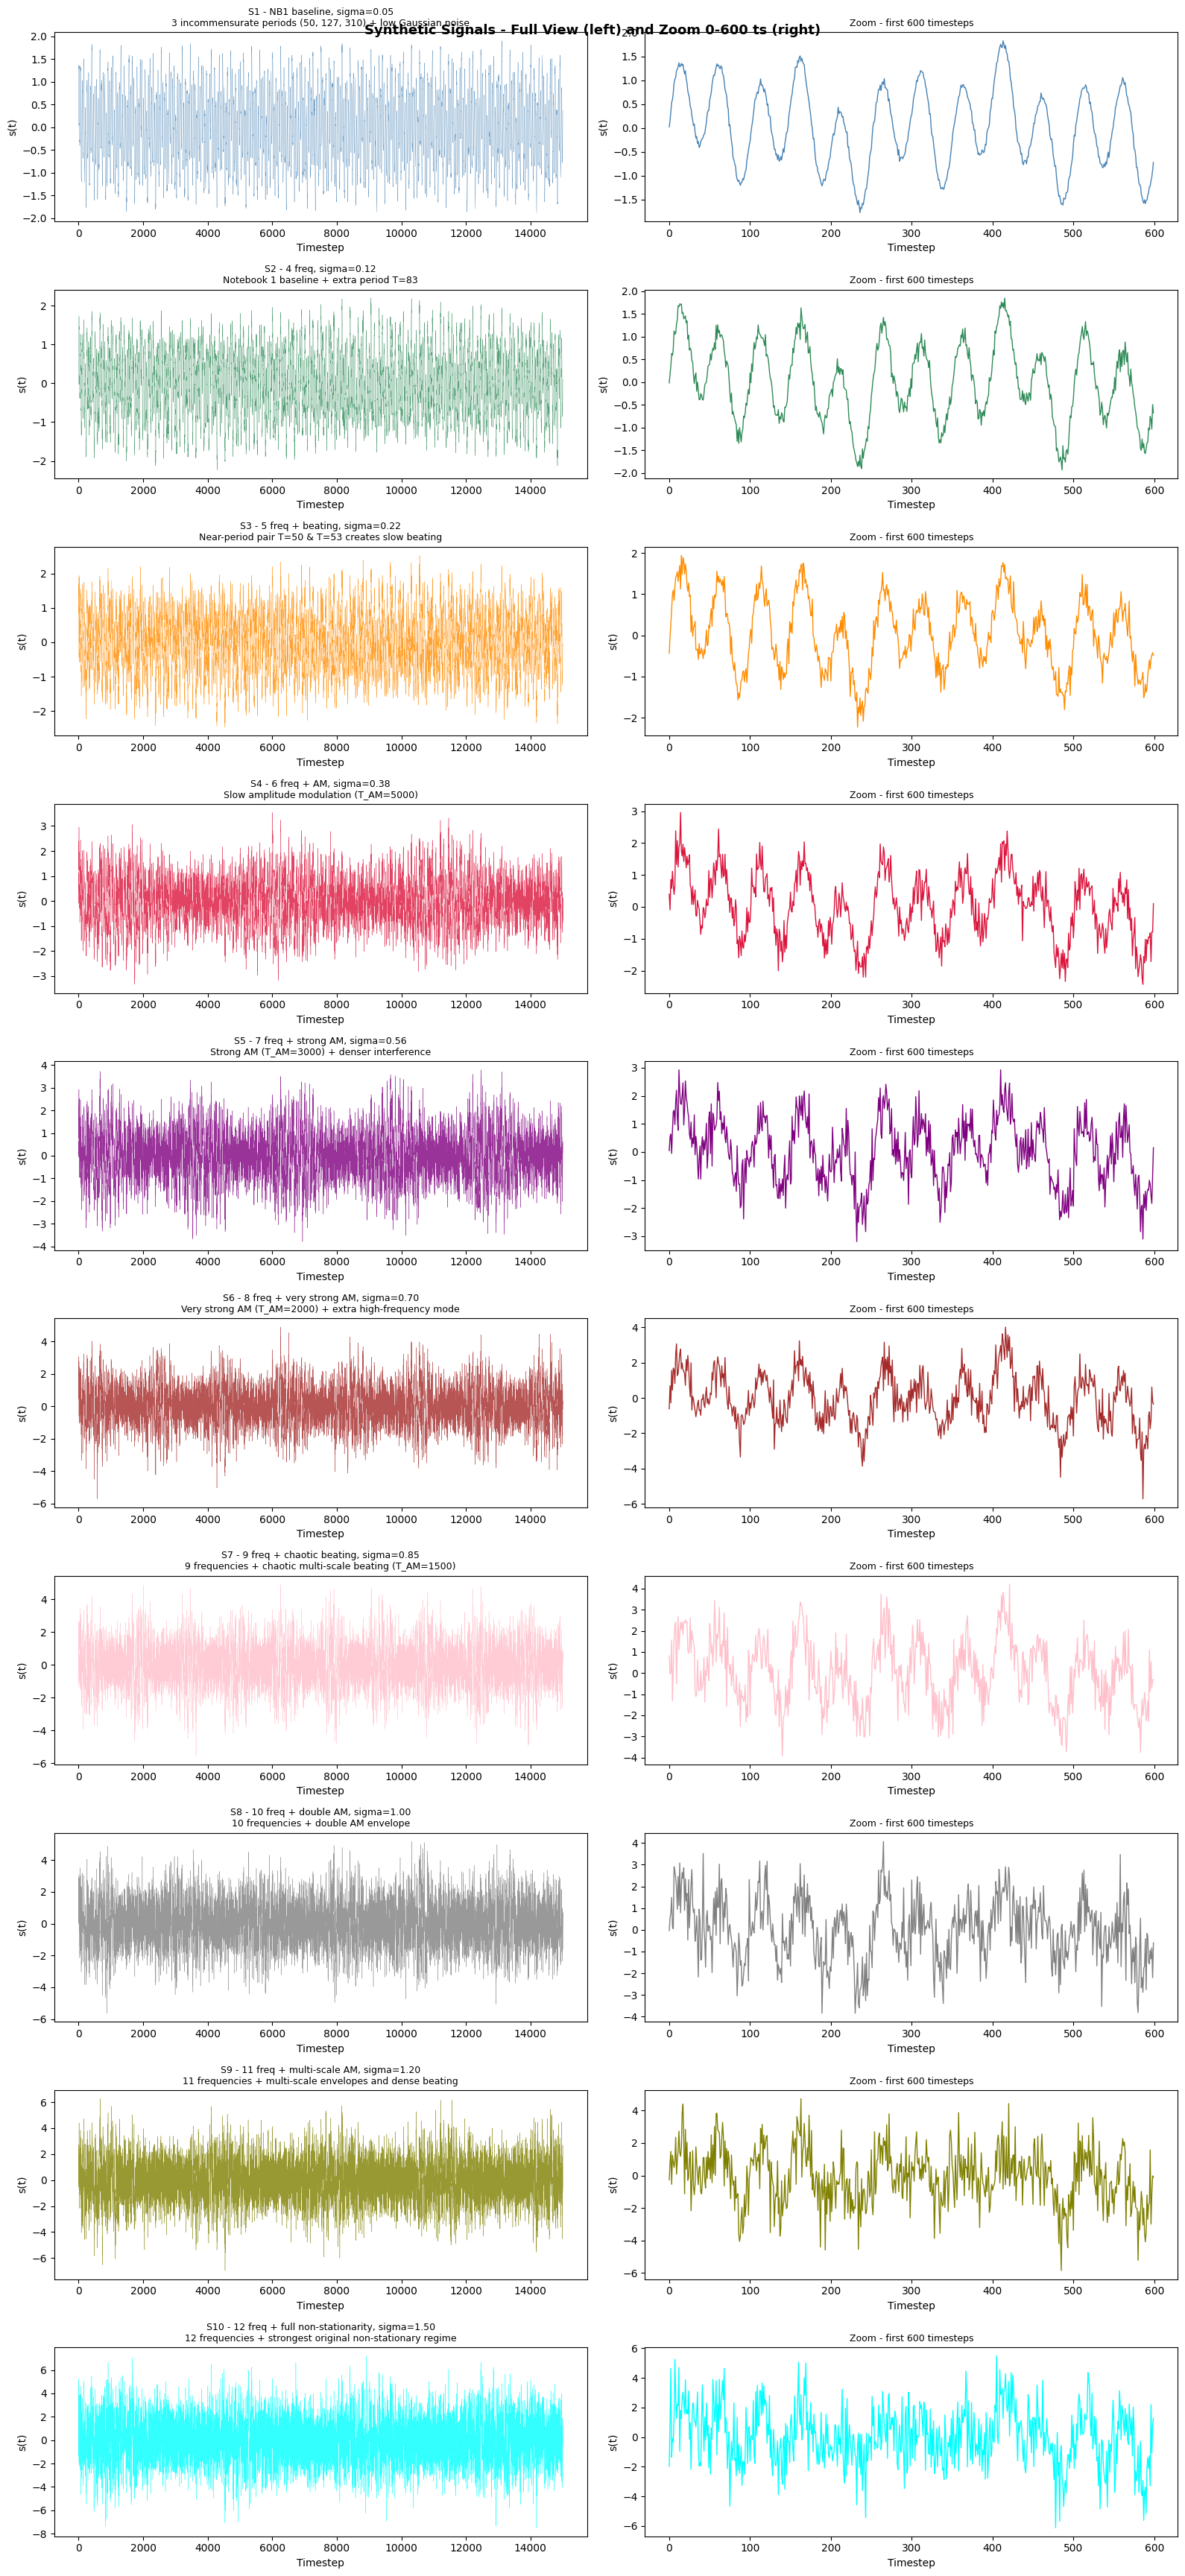

Figure saved → single_hp_outputs_3/signals_overview.png


In [ ]:
# ---------------------------------------------------------------------------
# Visualise all signals - full view + zoom
# ---------------------------------------------------------------------------
n_signals = len(SIGNALS)
fig, axes = plt.subplots(n_signals, 2, figsize=(16, 3.5 * n_signals))
fig.suptitle("Synthetic Signals - Full View (left) and Zoom 0-600 ts (right)",
             fontsize=13, fontweight="bold")

colors = ["steelblue", "seagreen", "darkorange", "crimson",
          "purple", "brown", "pink", "gray", "olive", "cyan"]
for row, (name, cfg) in enumerate(SIGNALS.items()):
    sig   = cfg["data"]
    color = colors[row % len(colors)]
    label = cfg["label"]

    # Full signal
    ax = axes[row, 0]
    ax.plot(t_axis, sig, lw=0.3, color=color, alpha=0.8)
    ax.set_title(f"{label}\n{cfg['desc']}", fontsize=9)
    ax.set_xlabel("Timestep"); ax.set_ylabel("s(t)")

    # Zoom
    ax = axes[row, 1]
    ax.plot(t_axis[:600], sig[:600], lw=1.0, color=color)
    ax.set_title(f"Zoom - first 600 timesteps", fontsize=9)
    ax.set_xlabel("Timestep"); ax.set_ylabel("s(t)")

plt.tight_layout()
plt.savefig("single_hp_outputs_3/signals_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved -> single_hp_outputs_3/signals_overview.png")

## 3. ESN Configuration & Helper Functions

To balance coverage and computation time, the parameter grids are slightly coarser than in
Notebooks 1 and 2 but still span the full range of interest for each architecture:

| Architecture | Parameter | Values |
|-------------|-----------|--------|
| ER | p (edge probability) | [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0] |
| WS | k (mean degree) | [2, 4, 8, 16, 32, 64] - p_rewire=0.3 fixed |
| WS | p_rewire | [0.0, 0.01, 0.05, 0.1, 0.3, 0.5, 0.8, 1.0] - k=10 fixed |
| BA | m (edges per new node) | [1, 2, 5, 10, 20, 50] |

### 3.1 Helper Functions

- `build_dataset(signal, lag)` - builds the lag-input supervised dataset
- `make_reservoir_matrix(N, topology, topo_params)` - constructs W with clip-only SR control
- `run_topology_shs(...)` - temporal CV sweep over one topology parameter
- `best_setting(df, param_name)` - returns the parameter value with lowest mean RMSE
- `plot_single_hp(...)` - 3-panel single hyperparameter study plot (RMSE dist · mean RMSE bar · R² dist)
- `run_signal_study(...)` - orchestrates the full 3-architecture sweep for one signal
- `plot_esn_prediction(...)` - trains on 75% / tests on 25%, returns predictions + metrics

In [5]:
# ===========================================================================
# Helper functions
# ===========================================================================

def build_dataset(signal, lag=LAG):
    """Build supervised lag-input dataset from a 1-D time series."""
    t_sig = len(signal)
    X = np.column_stack([signal[i : t_sig - lag + i] for i in range(lag)])
    y = signal[lag:].reshape(-1, 1)
    return X, y


def make_reservoir_matrix(N, topology, topo_params, clip_sr=1.1):
    """Build reservoir matrix with clip-only spectral-radius control."""
    rng = np.random.RandomState()
    if topology == "random":
        G = nx.erdos_renyi_graph(N, topo_params["p"], directed=True)
    elif topology == "small_world":
        k = int(topo_params["k"])
        if k % 2 != 0:
            k += 1
        k = min(max(k, 2), N - 1)
        G = nx.watts_strogatz_graph(N, k, p=topo_params["p_rewire"]).to_directed()
    elif topology == "scale_free":
        m = min(max(1, int(topo_params["m"])), N - 1)
        G = nx.barabasi_albert_graph(N, m).to_directed()
    else:
        raise ValueError(f"Unknown topology: {topology}")

    A = nx.adjacency_matrix(G).toarray().astype(np.float64)
    mask = A > 0
    W = np.zeros_like(A)
    W[mask] = rng.randn(mask.sum())

    eigs = np.linalg.eigvals(W)
    sr_natural = float(np.max(np.abs(eigs))) if mask.any() else 0.0
    clipped = sr_natural > clip_sr
    sr_actual = clip_sr if clipped else sr_natural
    if clipped:
        W *= clip_sr / sr_natural

    info = {
        "topology": topology,
        "N": N,
        "actual_density": mask.sum() / (N * N),
        "avg_degree": mask.sum(axis=1).mean(),
        "spectral_radius_natural": sr_natural,
        "spectral_radius_actual": sr_actual,
        "n_edges": int(mask.sum()),
        "clipped": clipped,
    }
    return W, info


def run_hp_search(signal_data, hp_configs, n_splits=N_SPLITS):
    """Notebook-1-style ESN hyperparameter search on a single signal."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    X, y = build_dataset(signal_data, lag=LAG)
    records = []

    rpy.set_seed(SEED)

    for cfg_idx, cfg in enumerate(hp_configs):
        N, sr, lr, ridge, washout = (
            int(cfg["N"]), cfg["sr"], cfg["lr"], cfg["ridge"], int(cfg["washout"])
        )
        fold_rmses = []

        for train_idx, test_idx in tscv.split(X):
            X_tr_f, y_tr_f = X[train_idx], y[train_idx]
            X_te_f, y_te_f = X[test_idx], y[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr_f)
            X_te = scaler.transform(X_te_f)

            try:
                reservoir = Reservoir(units=N, sr=sr, lr=lr)
                model = reservoir >> Ridge(ridge=ridge)
                model.fit(X_tr, y_tr_f, warmup=washout)
                y_pred = np.array(model.run(X_te)).reshape(-1)
                fold_rmses.append(np.sqrt(mean_squared_error(y_te_f.ravel(), y_pred)))
            except Exception:
                fold_rmses.append(np.nan)

        mean_rmse = float(np.nanmean(fold_rmses)) if fold_rmses else np.nan
        records.append({**cfg, "mean_rmse": mean_rmse})

        if (cfg_idx + 1) % 20 == 0 or cfg_idx == 0:
            valid = [row["mean_rmse"] for row in records if not np.isnan(row["mean_rmse"])]
            best_so_far = min(valid) if valid else float("nan")
            print(f"    [{cfg_idx + 1:3d}/{len(hp_configs)}]  best RMSE so far: {best_so_far:.5f}")

    df = pd.DataFrame(records).dropna(subset=["mean_rmse"])
    best = df.loc[df["mean_rmse"].idxmin()].to_dict()
    return best


def run_topology_shs(topology, param_name, param_values, esn_params,
                     fixed_topo=None, n_splits=N_SPLITS):
    """Single Hyperparameter Study over one structural topology parameter."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fixed = fixed_topo or {}
    records = []
    print(
        f"    [{topology}] sweep '{param_name}': "
        f"{len(param_values)} values x {n_splits} folds = {len(param_values) * n_splits} evals"
    )

    for val in param_values:
        topo_params = {**fixed, param_name: val}
        try:
            W, info = make_reservoir_matrix(esn_params["N"], topology, topo_params)
        except Exception as exc:
            print(f"      [MATRIX ERROR] {param_name}={val}: {exc}")
            for fi in range(n_splits):
                records.append({
                    param_name: val, "fold": fi, "rmse": np.nan,
                    "mae": np.nan, "r2": np.nan, "density": np.nan,
                    "sr_natural": np.nan, "train_time_s": np.nan,
                })
            continue

        if info["clipped"]:
            print(
                f"      [CLIP] {param_name}={val}: "
                f"sr_nat={info['spectral_radius_natural']:.3f} "
                f"-> {info['spectral_radius_actual']:.3f}"
            )

        for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
            X_tr_f, y_tr_f = X_all[train_idx], y_all[train_idx]
            X_te_f, y_te_f = X_all[test_idx], y_all[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr_f)
            X_te = scaler.transform(X_te_f)

            try:
                t0 = time.time()
                reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
                model = reservoir >> Ridge(ridge=esn_params["ridge"])
                model.fit(X_tr, y_tr_f, warmup=int(esn_params["washout"]))
                y_pred = np.array(model.run(X_te)).reshape(-1)
                y_true = y_te_f.ravel()
                records.append({
                    param_name: val,
                    "fold": fold_idx,
                    "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                    "mae": mean_absolute_error(y_true, y_pred),
                    "r2": r2_score(y_true, y_pred),
                    "density": info["actual_density"],
                    "sr_natural": info["spectral_radius_natural"],
                    "train_time_s": time.time() - t0,
                })
            except Exception as exc:
                print(f"      [ERROR] {param_name}={val}, fold {fold_idx}: {exc}")
                records.append({
                    param_name: val, "fold": fold_idx,
                    "rmse": np.nan, "mae": np.nan, "r2": np.nan,
                    "density": np.nan, "sr_natural": np.nan, "train_time_s": np.nan,
                })

    return pd.DataFrame(records)


def best_setting(df, param_name):
    """Return the parameter value with the lowest mean RMSE across folds."""
    agg = df.dropna(subset=["rmse"]).groupby(param_name)["rmse"].mean()
    return agg.idxmin()


def plot_single_hp(df, hp_name, hp_values, label_map=None, title="",
                   palette="colorblind", save_path=None):
    """Three-panel SHS plot: RMSE distribution, mean +/- std, and R² distribution."""
    labels = [label_map[v] if label_map else str(v) for v in hp_values]
    df_plt = df.dropna(subset=["rmse"]).copy()
    lbl_map = dict(zip(hp_values, labels))
    df_plt["_lbl"] = df_plt[hp_name].map(lbl_map)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    if title:
        fig.suptitle(title, fontsize=11, fontweight="bold", y=1.01)

    ax = axes[0]
    sns.boxplot(data=df_plt, x="_lbl", y="rmse", order=labels,
                palette=palette, width=0.5, fliersize=0, ax=ax)
    sns.stripplot(data=df_plt, x="_lbl", y="rmse", order=labels,
                  color="black", size=4, alpha=0.6, jitter=True, ax=ax)
    ax.set_xlabel(hp_name)
    ax.set_ylabel("RMSE")
    ax.set_title("RMSE - fold distribution")
    ax.tick_params(axis="x", rotation=45)

    ax = axes[1]
    summ = (
        df_plt.groupby("_lbl")["rmse"]
        .agg(["mean", "std"])
        .reindex(labels)
        .reset_index()
    )
    ax.errorbar(summ["_lbl"], summ["mean"], yerr=summ["std"],
                marker="o", capsize=6, linewidth=2, markersize=8,
                color="steelblue", elinewidth=1.5)
    ax.set_xlabel(hp_name)
    ax.set_ylabel("Mean RMSE +/- std")
    ax.set_title("Mean RMSE +/- std across folds")
    ax.tick_params(axis="x", rotation=45)

    ax = axes[2]
    sns.boxplot(data=df_plt, x="_lbl", y="r2", order=labels,
                palette=palette, width=0.5, fliersize=0, ax=ax)
    sns.stripplot(data=df_plt, x="_lbl", y="r2", order=labels,
                  color="black", size=4, alpha=0.6, jitter=True, ax=ax)
    ax.set_xlabel(hp_name)
    ax.set_ylabel("R²")
    ax.set_title("R² - fold distribution")
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
        print(f"    Figure saved -> {save_path}")
    plt.show()


def plot_esn_prediction(sig_name, sig_cfg, esn_params, topo, topo_params,
                        test_frac=0.25, zoom=400, ax_row=None):
    """Train on the first part of the signal and plot the held-out prediction."""
    signal = sig_cfg["data"]
    X_sig, y_sig = build_dataset(signal, lag=LAG)
    n = len(X_sig)
    n_train = int(n * (1 - test_frac))

    X_train, y_train = X_sig[:n_train], y_sig[:n_train]
    X_test, y_test = X_sig[n_train:], y_sig[n_train:]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train)
    X_te = scaler.transform(X_test)

    W, _ = make_reservoir_matrix(esn_params["N"], topo, topo_params)
    reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
    model = reservoir >> Ridge(ridge=esn_params["ridge"])
    model.fit(X_tr, y_train, warmup=int(esn_params["washout"]))
    y_pred = np.array(model.run(X_te)).reshape(-1)
    y_true = y_test.ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    t_all = np.arange(len(signal))
    t_test = t_all[LAG + n_train:]

    own_fig = ax_row is None
    if own_fig:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    else:
        axes = ax_row

    ax = axes[0]
    ax.plot(t_all[:LAG + n_train], signal[:LAG + n_train],
            lw=0.25, color="lightgray", label="Training signal")
    ax.plot(t_test, y_true, lw=0.8, color="steelblue", label="Real (test)")
    ax.plot(t_test, y_pred, lw=0.8, color="tomato", alpha=0.85, label="Predicted")
    ax.axvline(LAG + n_train, color="black", ls="--", lw=0.8)
    ax.set_title(f"{sig_name}   RMSE={rmse:.4f}   R²={r2:.4f}", fontsize=9)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("s(t)")
    ax.legend(loc="upper left", fontsize=7)

    ax = axes[1]
    ax.plot(t_test[:zoom], y_true[:zoom], lw=1.2, color="steelblue", label="Real")
    ax.plot(t_test[:zoom], y_pred[:zoom], lw=1.2, color="tomato", ls="--", label="Predicted")
    ax.set_title(f"Zoom - first {zoom} test timesteps", fontsize=9)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("s(t)")
    ax.legend(fontsize=7)

    if own_fig:
        plt.tight_layout()
        plt.show()

    return y_true, y_pred, rmse, r2


def run_signal_study(sig_name, sig_cfg, esn_params,
                     er_p_values, ws_k_values, ws_prw_values, ba_m_values,
                     fixed_k=4, fixed_p_rewire=0.1,
                     output_dir="single_hp_outputs_3"):
    """Full topology SHS study for one signal at its own best ESN parameters."""
    global X_all, y_all
    signal = sig_cfg["data"]
    X_all, y_all = build_dataset(signal, lag=LAG)

    ws_k_values_valid = []
    for val in ws_k_values:
        k = min(max(2, int(val)), esn_params["N"] - 1)
        if k % 2 != 0:
            k = max(2, k - 1)
        if 2 <= k < esn_params["N"] and k not in ws_k_values_valid:
            ws_k_values_valid.append(k)
    ws_k_values_valid = sorted(ws_k_values_valid)

    fixed_k_local = min(max(2, int(fixed_k)), esn_params["N"] - 1)
    if fixed_k_local % 2 != 0:
        fixed_k_local = max(2, fixed_k_local - 1)

    ba_m_values_valid = sorted({
        min(max(1, int(m)), esn_params["N"] - 1) for m in ba_m_values
    })

    print(f"\n{'=' * 62}")
    print(f"  {sig_cfg['label']}")
    print(f"  {sig_cfg['desc']}")
    print(f"  Dataset: X={X_all.shape}  y={y_all.shape}")
    print(f"  ESN params: {esn_params}")
    print(f"{'=' * 62}")
    t_start = time.time()

    print("\n[ER] Sweeping connection probability p ...")
    df_er = run_topology_shs("random", "p", er_p_values, esn_params)
    df_er.to_csv(f"{output_dir}/shs_{sig_name}_er_p.csv", index=False)
    plot_single_hp(
        df_er, "p", er_p_values,
        title=f"[{sig_name}] ER - Single Hyperparameter Study on p",
        save_path=f"{output_dir}/shs_{sig_name}_er_p.png",
    )

    print(f"\n[WS] Sweeping mean degree k (p_rewire={fixed_p_rewire} fixed) ...")
    df_ws_k = run_topology_shs(
        "small_world", "k", ws_k_values_valid, esn_params,
        fixed_topo={"p_rewire": fixed_p_rewire},
    )
    df_ws_k.to_csv(f"{output_dir}/shs_{sig_name}_ws_k.csv", index=False)
    plot_single_hp(
        df_ws_k, "k", ws_k_values_valid,
        title=f"[{sig_name}] WS - Single Hyperparameter Study on k (p_rewire={fixed_p_rewire} fixed)",
        save_path=f"{output_dir}/shs_{sig_name}_ws_k.png",
    )

    print(f"\n[WS] Sweeping rewiring prob p_rewire (k={fixed_k_local} fixed) ...")
    df_ws_prw = run_topology_shs(
        "small_world", "p_rewire", ws_prw_values, esn_params,
        fixed_topo={"k": fixed_k_local},
    )
    df_ws_prw.to_csv(f"{output_dir}/shs_{sig_name}_ws_prw.csv", index=False)
    ws_prw_labels = {v: str(v) for v in ws_prw_values}
    plot_single_hp(
        df_ws_prw, "p_rewire", ws_prw_values, label_map=ws_prw_labels,
        title=f"[{sig_name}] WS - Single Hyperparameter Study on p_rewire (k={fixed_k_local} fixed)",
        save_path=f"{output_dir}/shs_{sig_name}_ws_prw.png",
    )

    print("\n[BA] Sweeping edges-per-new-node m ...")
    df_ba = run_topology_shs("scale_free", "m", ba_m_values_valid, esn_params)
    df_ba.to_csv(f"{output_dir}/shs_{sig_name}_ba_m.csv", index=False)
    ba_labels = {v: str(v) for v in ba_m_values_valid}
    plot_single_hp(
        df_ba, "m", ba_m_values_valid, label_map=ba_labels,
        title=f"[{sig_name}] BA - Single Hyperparameter Study on m",
        save_path=f"{output_dir}/shs_{sig_name}_ba_m.png",
    )

    best_er_p = best_setting(df_er, "p")
    best_ws_k = best_setting(df_ws_k, "k")
    best_ws_prw = best_setting(df_ws_prw, "p_rewire")
    best_ba_m = best_setting(df_ba, "m")

    rmse_er = df_er[df_er["p"] == best_er_p]["rmse"].mean()
    rmse_ws_k = df_ws_k[df_ws_k["k"] == best_ws_k]["rmse"].mean()
    rmse_ws_prw = df_ws_prw[df_ws_prw["p_rewire"] == best_ws_prw]["rmse"].mean()
    rmse_ba = df_ba[df_ba["m"] == best_ba_m]["rmse"].mean()
    rmse_ws_best = min(rmse_ws_k, rmse_ws_prw)

    elapsed = time.time() - t_start
    print(f"\n{'-' * 62}")
    print(f"  Best ER  : p={best_er_p}          -> mean RMSE = {rmse_er:.5f}")
    print(f"  Best WS  : k={best_ws_k}, p_rewire={best_ws_prw}")
    print(f"              RMSE(k)={rmse_ws_k:.5f}  RMSE(prw)={rmse_ws_prw:.5f}  best={rmse_ws_best:.5f}")
    print(f"  Best BA  : m={best_ba_m}          -> mean RMSE = {rmse_ba:.5f}")
    print(f"  Elapsed  : {elapsed / 60:.1f} min")

    return {
        "label": sig_cfg["label"],
        "n_components": sig_cfg["n_components"],
        "noise_std": sig_cfg["noise_std"],
        "extra": sig_cfg["extra"],
        "esn_params": dict(esn_params),
        "ER": {"df": df_er, "best_p": best_er_p, "best_rmse": rmse_er},
        "WS_k": {"df": df_ws_k, "best_k": best_ws_k, "best_rmse": rmse_ws_k},
        "WS_p": {"df": df_ws_prw, "best_prw": best_ws_prw, "best_rmse": rmse_ws_prw},
        "BA": {"df": df_ba, "best_m": best_ba_m, "best_rmse": rmse_ba},
        "WS_best_rmse": rmse_ws_best,
    }


print("All helper functions defined.")


All helper functions defined.


In [6]:
# Container for all study results - populated as we run each signal below
study_results = {}

### 3.2 Per-Signal ESN Hyperparameter Optimisation

Before studying topology effects, we tune the core ESN hyperparameters
`(N, sr, lr, ridge, washout)` independently for **all ten signals** using the
same refined Phase-A grid used in Notebook 1 and the same **10-fold temporal CV**
protocol.

This serves two purposes:

1. every signal is evaluated at its own best operating point;
2. `S1` can be checked directly against Notebook 1 because it is now exactly the
   same baseline signal.


In [7]:
# ---------------------------------------------------------------------------
# Per-signal Phase-A optimisation on the first ten signals
# ---------------------------------------------------------------------------
HP_GRID = {
    "N":       [25, 50, 100, 300, 400],
    "sr":      [0.9, 1.1, 1.3],
    "lr":      [0.05, 0.1, 0.2],
    "ridge":   [1e-3, 1e-2, 5e-2],
    "washout": [10],
}
HP_CONFIGS = list(ParameterGrid(HP_GRID))
PHASE_A_SIGNAL_NAMES = SIGNAL_ORDER

print(
    f"Phase-A grid: {len(HP_CONFIGS)} configs x {N_SPLITS} folds x "
    f"{len(PHASE_A_SIGNAL_NAMES)} signals = {len(HP_CONFIGS) * N_SPLITS * len(PHASE_A_SIGNAL_NAMES)} total evals\n"
)

BEST_PARAMS_PER_SIGNAL = {}
_hp_best_rmse = {}
best_param_rows = []

for sig_name in PHASE_A_SIGNAL_NAMES:
    print(f"\n{'=' * 55}")
    print(f"  HP search for {sig_name}: {SIGNALS[sig_name]['label']}")
    print(f"{'=' * 55}")

    best = run_hp_search(SIGNALS[sig_name]["data"], HP_CONFIGS)
    params = {
        "N": int(best["N"]),
        "sr": float(best["sr"]),
        "lr": float(best["lr"]),
        "ridge": float(best["ridge"]),
        "washout": int(best["washout"]),
    }
    BEST_PARAMS_PER_SIGNAL[sig_name] = params
    _hp_best_rmse[sig_name] = float(best["mean_rmse"])

    best_param_rows.append({
        "Signal": sig_name,
        "N": params["N"],
        "sr": params["sr"],
        "lr": params["lr"],
        "ridge": params["ridge"],
        "washout": params["washout"],
        "CV_RMSE": _hp_best_rmse[sig_name],
    })
    print(f"  -> Best: {params}  (CV RMSE={best['mean_rmse']:.5f})")

df_best_params = pd.DataFrame(best_param_rows)
df_best_params.to_csv("single_hp_outputs_3/best_params_per_signal.csv", index=False)

print(f"\n{'=' * 81}")
print(
    df_best_params.to_string(
        index=False,
        formatters={
            "sr": "{:.2f}".format,
            "lr": "{:.2f}".format,
            "ridge": "{:.0e}".format,
            "CV_RMSE": "{:.5f}".format,
        },
    )
)
print(f"{'=' * 81}")
print("\nSaved -> single_hp_outputs_3/best_params_per_signal.csv")

NOTEBOOK1_S1_REFERENCE = {
    "N": 400,
    "sr": 1.1,
    "lr": 0.05,
    "ridge": 1e-2,
    "washout": 10,
}
s1_match = all(
    np.isclose(BEST_PARAMS_PER_SIGNAL["S1"][key], value)
    for key, value in NOTEBOOK1_S1_REFERENCE.items()
)

print("\nS1 consistency check against Notebook 1 refined reference")
print(f"  Notebook 3 S1 best params : {BEST_PARAMS_PER_SIGNAL['S1']}")
print(f"  Notebook 1 reference      : {NOTEBOOK1_S1_REFERENCE}")
print(f"  Exact match               : {s1_match}")


Phase-A grid: 135 configs x 10 folds x 10 signals = 13500 total evals


  HP search for S1: S1 - NB1 baseline, sigma=0.05
    [  1/135]  best RMSE so far: 0.07490
    [ 20/135]  best RMSE so far: 0.07326
    [ 40/135]  best RMSE so far: 0.06178
    [ 60/135]  best RMSE so far: 0.05688
    [ 80/135]  best RMSE so far: 0.05688
    [100/135]  best RMSE so far: 0.05448
    [120/135]  best RMSE so far: 0.05439
  -> Best: {'N': 400, 'sr': 1.3, 'lr': 0.05, 'ridge': 0.05, 'washout': 10}  (CV RMSE=0.05439)

  HP search for S2: S2 - 4 freq, sigma=0.12
    [  1/135]  best RMSE so far: 0.15672
    [ 20/135]  best RMSE so far: 0.15168
    [ 40/135]  best RMSE so far: 0.14260
    [ 60/135]  best RMSE so far: 0.13924
    [ 80/135]  best RMSE so far: 0.13777
    [100/135]  best RMSE so far: 0.13598
    [120/135]  best RMSE so far: 0.13598
  -> Best: {'N': 300, 'sr': 1.3, 'lr': 0.1, 'ridge': 0.05, 'washout': 10}  (CV RMSE=0.13598)

  HP search for S3: S3 - 5 freq + beating, sigma=0.22
    [  1/135]  be

### 3.3 Preliminary CV — Canonical Best Topology Parameters

Using each signal's individually tuned ESN hyperparameters, we sweep the key topology parameters
on **Signal S1** (the simplest signal) to identify canonical starting ranges. These are used
as reference values in the final comparison grid (Section 10).

In [8]:
# ---------------------------------------------------------------------------
# Preliminary Cross-Validation on S1 (uses S1-specific best HP)
# ---------------------------------------------------------------------------
BEST_PARAMS = BEST_PARAMS_PER_SIGNAL["S1"]

N = BEST_PARAMS["N"]

ER_P_VALUES = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
WS_K_VALUES = [v for v in [0, 2, 3, 4, 8, 16, 32, 64, N // 2, N - 1] if v < N]
WS_PRW_VALUES = [0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
FIXED_K = min(10, N - 1)
FIXED_P_REWIRE = 0.3

BA_M_VALUES = []
m_val = 1
while m_val < N:
    BA_M_VALUES.append(m_val)
    m_val *= 2

X_all, y_all = build_dataset(SIGNALS["S1"]["data"], lag=LAG)

print("=" * 62)
print("  Preliminary CV on S1 — canonical topology param search")
print(f"  {N_SPLITS}-fold temporal CV, reservoir N={BEST_PARAMS['N']}")
print(f"  ESN params: sr={BEST_PARAMS['sr']}  lr={BEST_PARAMS['lr']}")
print(f"              ridge={BEST_PARAMS['ridge']}  washout={BEST_PARAMS['washout']}")
print("=" * 62)

print("\n[ER] Sweeping p ...")
df_shs_er = run_topology_shs("random", "p", ER_P_VALUES, BEST_PARAMS)
CANONICAL_ER_P = best_setting(df_shs_er, "p")

print(f"\n[WS] Sweeping k  (p_rewire={FIXED_P_REWIRE} fixed) ...")
df_shs_ws_k = run_topology_shs(
    "small_world", "k", WS_K_VALUES, BEST_PARAMS,
    fixed_topo={"p_rewire": FIXED_P_REWIRE},
)
CANONICAL_WS_K = best_setting(df_shs_ws_k, "k")

print(f"\n[WS] Sweeping p_rewire  (k={FIXED_K} fixed) ...")
df_shs_ws_prw = run_topology_shs(
    "small_world", "p_rewire", WS_PRW_VALUES, BEST_PARAMS,
    fixed_topo={"k": FIXED_K},
)
CANONICAL_WS_PRW = best_setting(df_shs_ws_prw, "p_rewire")

print("\n[BA] Sweeping m ...")
df_shs_ba = run_topology_shs("scale_free", "m", BA_M_VALUES, BEST_PARAMS)
CANONICAL_BA_M = best_setting(df_shs_ba, "m")

print(f"\n{'-' * 62}")
print("  Canonical best topology parameters  (used in Section 9):")
print(f"    ER  : p        = {CANONICAL_ER_P}")
print(f"    WS  : k        = {CANONICAL_WS_K}")
print(f"    WS  : p_rewire = {CANONICAL_WS_PRW}")
print(f"    BA  : m        = {CANONICAL_BA_M}")
print(f"{'-' * 62}")


  Preliminary CV on S1 — canonical topology param search
  10-fold temporal CV, reservoir N=400
  ESN params: sr=1.3  lr=0.05
              ridge=0.05  washout=10

[ER] Sweeping p ...
    [random] sweep 'p': 11 values x 10 folds = 110 evals
      [CLIP] p=0.1: sr_nat=6.479 -> 1.100
      [CLIP] p=0.2: sr_nat=9.134 -> 1.100
      [CLIP] p=0.3: sr_nat=11.464 -> 1.100
      [CLIP] p=0.4: sr_nat=13.102 -> 1.100
      [CLIP] p=0.5: sr_nat=14.551 -> 1.100
      [CLIP] p=0.6: sr_nat=15.923 -> 1.100
      [CLIP] p=0.7: sr_nat=17.010 -> 1.100
      [CLIP] p=0.8: sr_nat=18.194 -> 1.100
      [CLIP] p=0.9: sr_nat=19.550 -> 1.100
      [CLIP] p=1.0: sr_nat=21.006 -> 1.100

[WS] Sweeping k  (p_rewire=0.3 fixed) ...
    [small_world] sweep 'k': 10 values x 10 folds = 100 evals
      [CLIP] k=0: sr_nat=2.725 -> 1.100
      [CLIP] k=2: sr_nat=2.570 -> 1.100
      [CLIP] k=3: sr_nat=2.956 -> 1.100
      [CLIP] k=4: sr_nat=3.472 -> 1.100
      [CLIP] k=8: sr_nat=3.763 -> 1.100
      [CLIP] k=16: sr_nat=

## 4. Topology Study - Signal S1
**Notebook 1 baseline: 3 incommensurate frequencies, sigma=0.05** - this is now
exactly the same synthetic signal used in Notebook 1, so the topology study starts
from the cleanest and easiest benchmark in the suite.

Expected behaviour: architecture differences should be small because the signal is
highly regular, and the main check is whether the topology ranking stays consistent
with Notebook 1.



  S1 - NB1 baseline, sigma=0.05
  3 incommensurate periods (50, 127, 310) + low Gaussian noise
  Dataset: X=(14990, 10)  y=(14990, 1)
  ESN params: {'N': 400, 'sr': 1.3, 'lr': 0.05, 'ridge': 0.05, 'washout': 10}

[ER] Sweeping connection probability p ...
    [random] sweep 'p': 11 values x 10 folds = 110 evals
      [CLIP] p=0.1: sr_nat=6.853 -> 1.100
      [CLIP] p=0.2: sr_nat=9.101 -> 1.100
      [CLIP] p=0.3: sr_nat=11.251 -> 1.100
      [CLIP] p=0.4: sr_nat=12.892 -> 1.100
      [CLIP] p=0.5: sr_nat=14.469 -> 1.100
      [CLIP] p=0.6: sr_nat=15.974 -> 1.100
      [CLIP] p=0.7: sr_nat=17.598 -> 1.100
      [CLIP] p=0.8: sr_nat=18.411 -> 1.100
      [CLIP] p=0.9: sr_nat=19.748 -> 1.100
      [CLIP] p=1.0: sr_nat=21.088 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S1_er_p.png


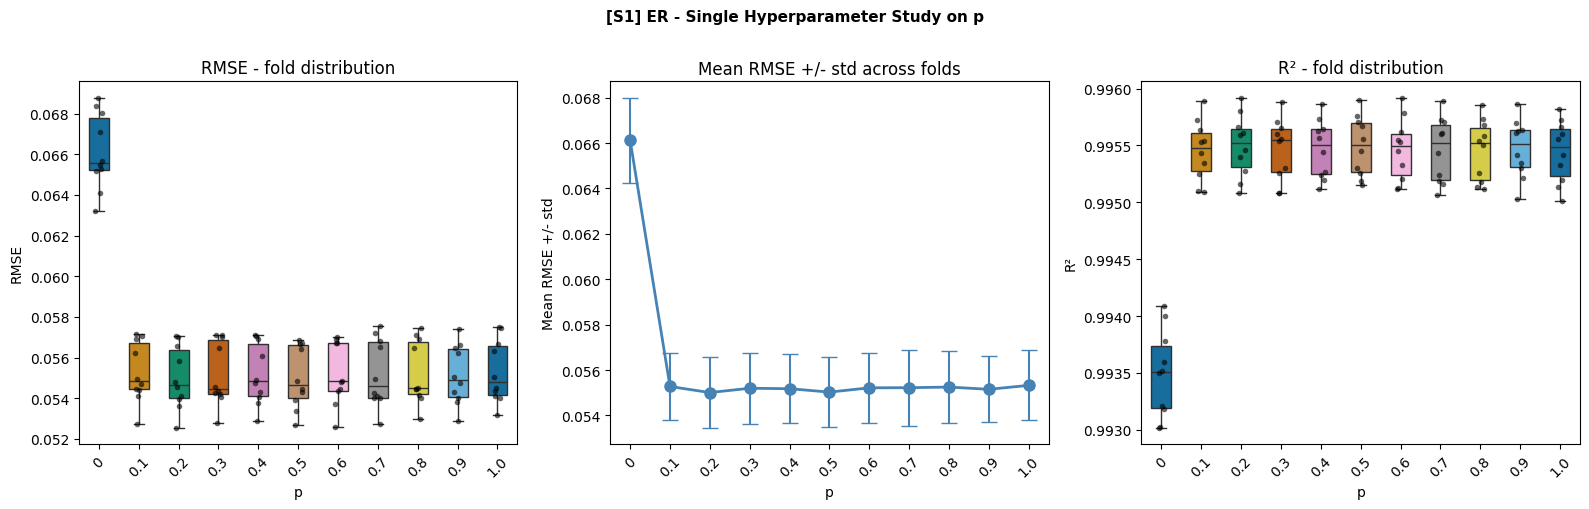


[WS] Sweeping mean degree k (p_rewire=0.3 fixed) ...
    [small_world] sweep 'k': 8 values x 10 folds = 80 evals
      [CLIP] k=2: sr_nat=2.640 -> 1.100
      [CLIP] k=4: sr_nat=2.711 -> 1.100
      [CLIP] k=8: sr_nat=3.538 -> 1.100
      [CLIP] k=16: sr_nat=4.970 -> 1.100
      [CLIP] k=32: sr_nat=5.995 -> 1.100
      [CLIP] k=64: sr_nat=8.170 -> 1.100
      [CLIP] k=200: sr_nat=14.433 -> 1.100
      [CLIP] k=398: sr_nat=20.246 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S1_ws_k.png


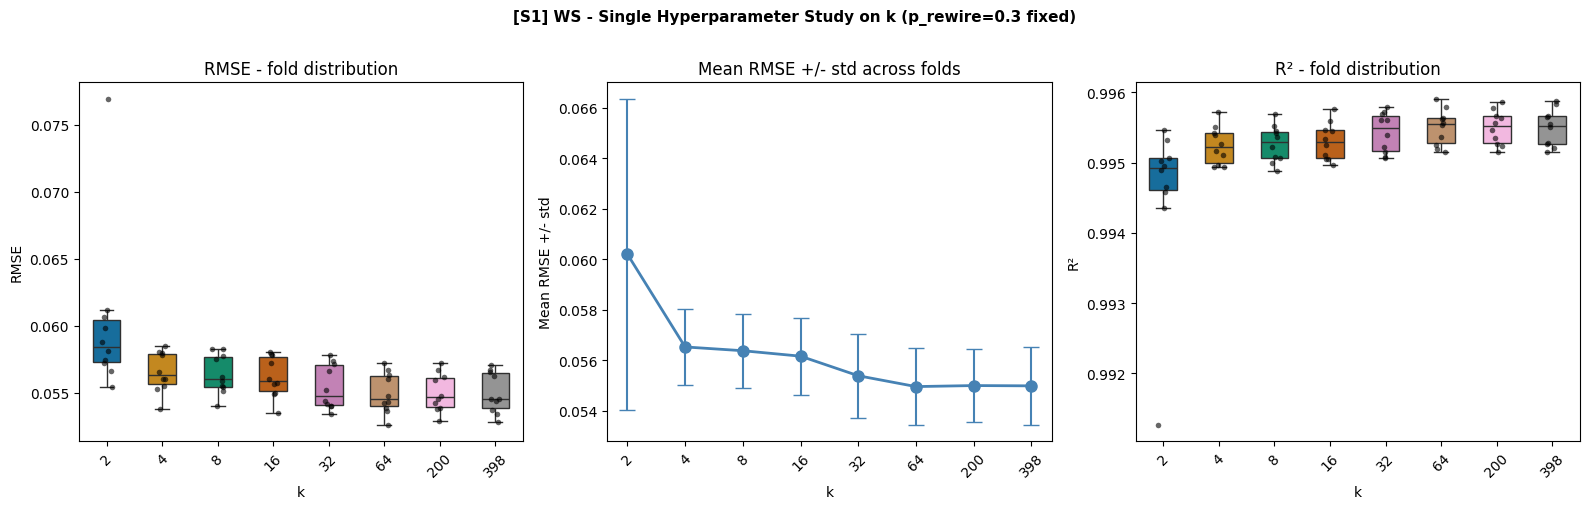


[WS] Sweeping rewiring prob p_rewire (k=10 fixed) ...
    [small_world] sweep 'p_rewire': 11 values x 10 folds = 110 evals
      [CLIP] p_rewire=0: sr_nat=3.954 -> 1.100
      [CLIP] p_rewire=0.001: sr_nat=3.986 -> 1.100
      [CLIP] p_rewire=0.005: sr_nat=4.198 -> 1.100
      [CLIP] p_rewire=0.01: sr_nat=4.118 -> 1.100
      [CLIP] p_rewire=0.02: sr_nat=4.504 -> 1.100
      [CLIP] p_rewire=0.05: sr_nat=4.184 -> 1.100
      [CLIP] p_rewire=0.1: sr_nat=4.033 -> 1.100
      [CLIP] p_rewire=0.2: sr_nat=3.759 -> 1.100
      [CLIP] p_rewire=0.3: sr_nat=4.741 -> 1.100
      [CLIP] p_rewire=0.5: sr_nat=3.405 -> 1.100
      [CLIP] p_rewire=1.0: sr_nat=3.617 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S1_ws_prw.png


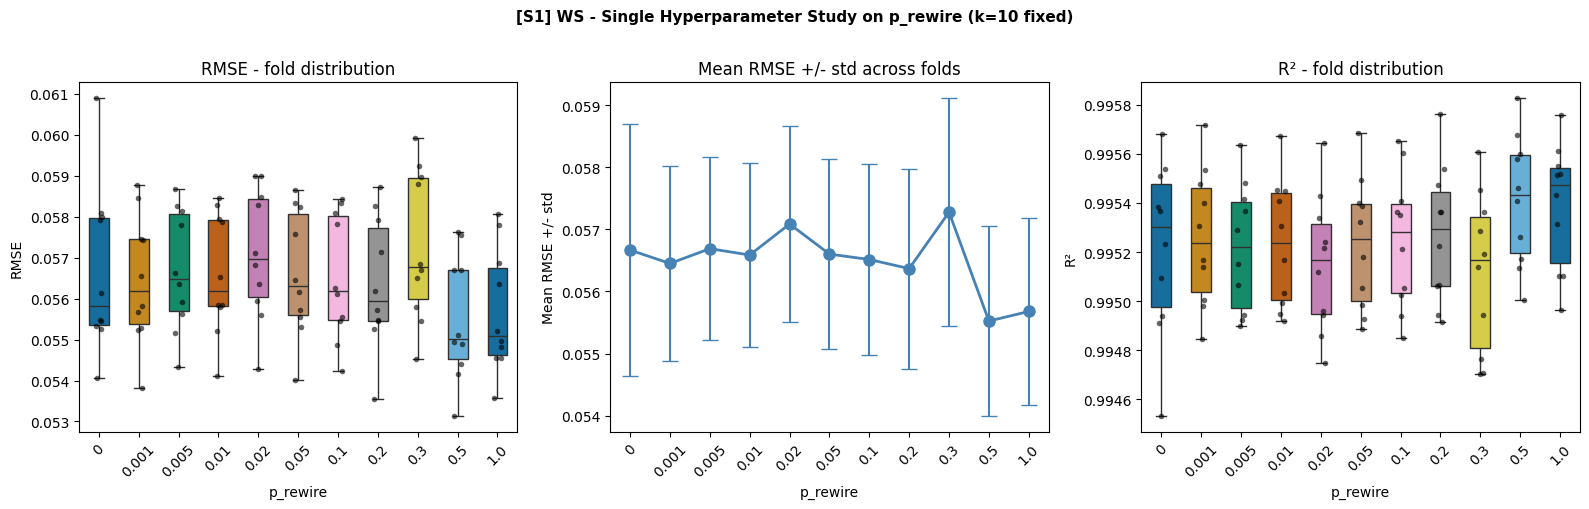


[BA] Sweeping edges-per-new-node m ...
    [scale_free] sweep 'm': 9 values x 10 folds = 90 evals
      [CLIP] m=1: sr_nat=3.487 -> 1.100
      [CLIP] m=2: sr_nat=4.404 -> 1.100
      [CLIP] m=4: sr_nat=5.015 -> 1.100
      [CLIP] m=8: sr_nat=5.235 -> 1.100
      [CLIP] m=16: sr_nat=7.566 -> 1.100
      [CLIP] m=32: sr_nat=8.918 -> 1.100
      [CLIP] m=64: sr_nat=11.377 -> 1.100
      [CLIP] m=128: sr_nat=14.438 -> 1.100
      [CLIP] m=256: sr_nat=15.295 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S1_ba_m.png


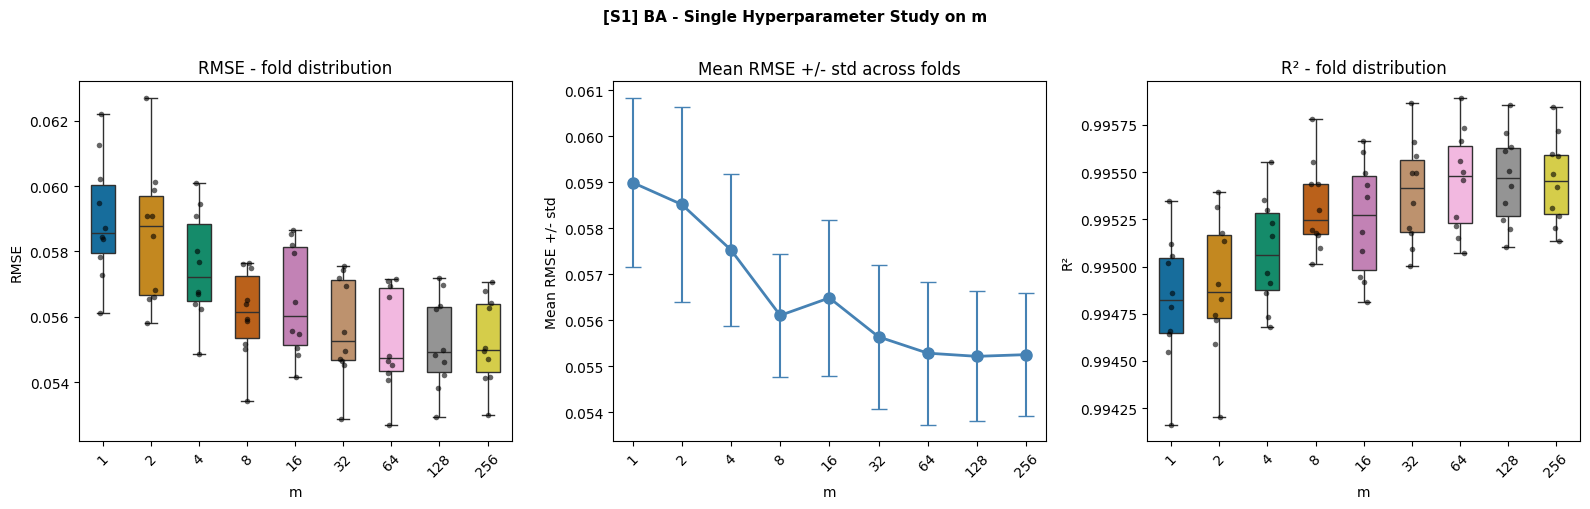


--------------------------------------------------------------
  Best ER  : p=0.2          -> mean RMSE = 0.05501
  Best WS  : k=64, p_rewire=0.5
              RMSE(k)=0.05496  RMSE(prw)=0.05552  best=0.05496
  Best BA  : m=128          -> mean RMSE = 0.05522
  Elapsed  : 2.4 min


In [9]:
study_results["S1"] = run_signal_study(
    "S1", SIGNALS["S1"], BEST_PARAMS_PER_SIGNAL["S1"],
    ER_P_VALUES, WS_K_VALUES, WS_PRW_VALUES, BA_M_VALUES,
    fixed_k=FIXED_K, fixed_p_rewire=FIXED_P_REWIRE,
)


## 5. Topology Study - Signal S2
**4 frequencies, sigma=0.12** - this signal adds a fourth incommensurate period
`T=83` on top of the Notebook 1 baseline, increasing the memory requirement while
remaining fully stationary.

Expected behaviour: architecture differences should still be moderate, but denser
or more structured recurrent graphs may start to pull ahead over purely random ER.



  S2 - 4 freq, sigma=0.12
  Notebook 1 baseline + extra period T=83
  Dataset: X=(14990, 10)  y=(14990, 1)
  ESN params: {'N': 300, 'sr': 1.3, 'lr': 0.1, 'ridge': 0.05, 'washout': 10}

[ER] Sweeping connection probability p ...
    [random] sweep 'p': 11 values x 10 folds = 110 evals
      [CLIP] p=0.1: sr_nat=5.769 -> 1.100
      [CLIP] p=0.2: sr_nat=7.791 -> 1.100
      [CLIP] p=0.3: sr_nat=9.855 -> 1.100
      [CLIP] p=0.4: sr_nat=11.252 -> 1.100
      [CLIP] p=0.5: sr_nat=12.376 -> 1.100
      [CLIP] p=0.6: sr_nat=13.977 -> 1.100
      [CLIP] p=0.7: sr_nat=15.550 -> 1.100
      [CLIP] p=0.8: sr_nat=16.035 -> 1.100
      [CLIP] p=0.9: sr_nat=16.531 -> 1.100
      [CLIP] p=1.0: sr_nat=18.662 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S2_er_p.png


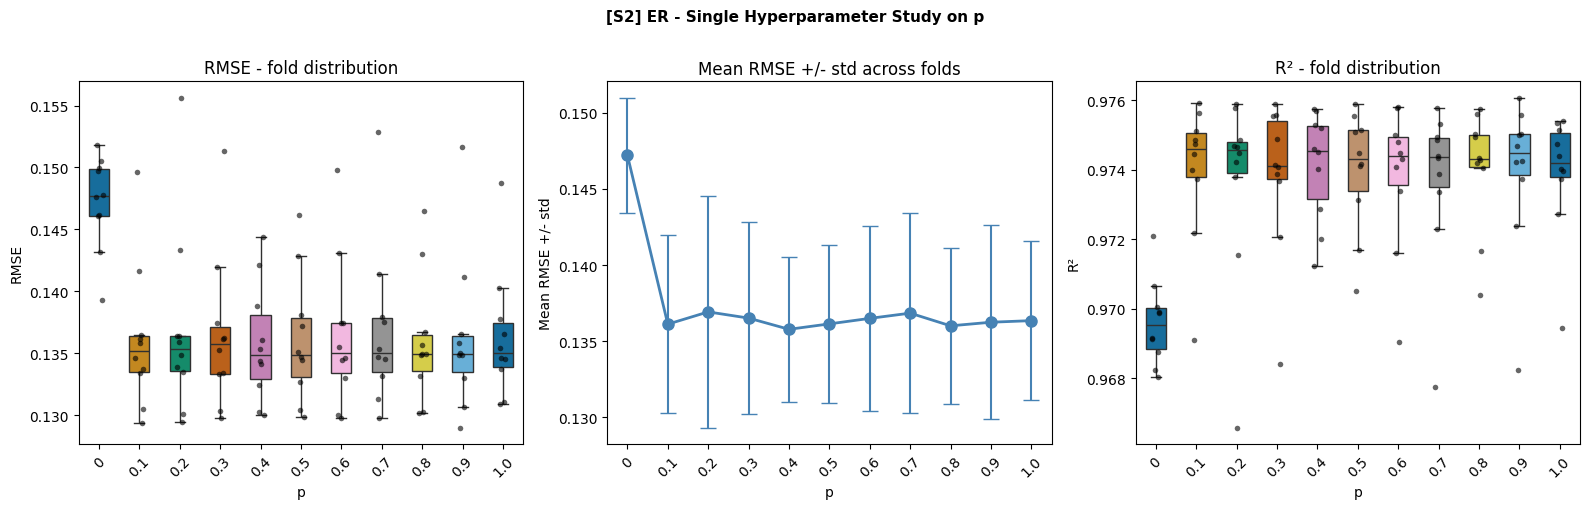


[WS] Sweeping mean degree k (p_rewire=0.3 fixed) ...
    [small_world] sweep 'k': 8 values x 10 folds = 80 evals
      [CLIP] k=2: sr_nat=2.510 -> 1.100
      [CLIP] k=4: sr_nat=2.650 -> 1.100
      [CLIP] k=8: sr_nat=3.666 -> 1.100
      [CLIP] k=16: sr_nat=4.201 -> 1.100
      [CLIP] k=32: sr_nat=5.884 -> 1.100
      [CLIP] k=64: sr_nat=8.132 -> 1.100
      [CLIP] k=200: sr_nat=14.499 -> 1.100
      [CLIP] k=298: sr_nat=17.479 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S2_ws_k.png


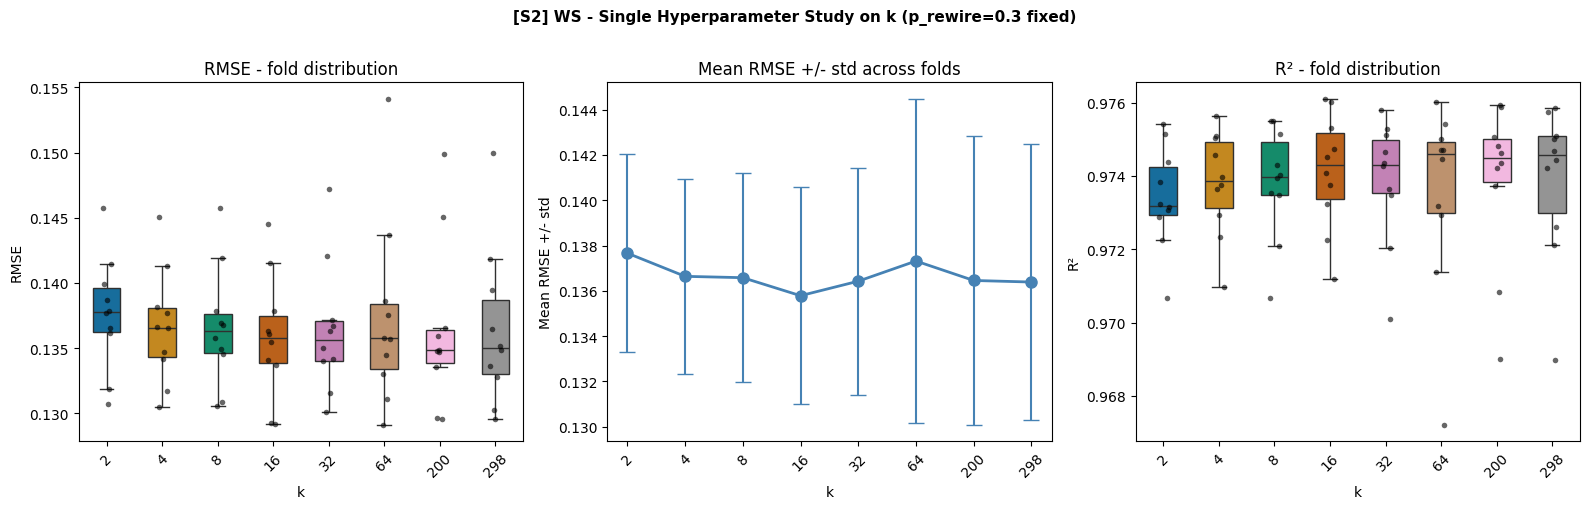


[WS] Sweeping rewiring prob p_rewire (k=10 fixed) ...
    [small_world] sweep 'p_rewire': 11 values x 10 folds = 110 evals
      [CLIP] p_rewire=0: sr_nat=3.740 -> 1.100
      [CLIP] p_rewire=0.001: sr_nat=3.907 -> 1.100
      [CLIP] p_rewire=0.005: sr_nat=3.871 -> 1.100
      [CLIP] p_rewire=0.01: sr_nat=4.199 -> 1.100
      [CLIP] p_rewire=0.02: sr_nat=4.216 -> 1.100
      [CLIP] p_rewire=0.05: sr_nat=3.791 -> 1.100
      [CLIP] p_rewire=0.1: sr_nat=3.964 -> 1.100
      [CLIP] p_rewire=0.2: sr_nat=3.917 -> 1.100
      [CLIP] p_rewire=0.3: sr_nat=4.016 -> 1.100
      [CLIP] p_rewire=0.5: sr_nat=3.786 -> 1.100
      [CLIP] p_rewire=1.0: sr_nat=3.751 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S2_ws_prw.png


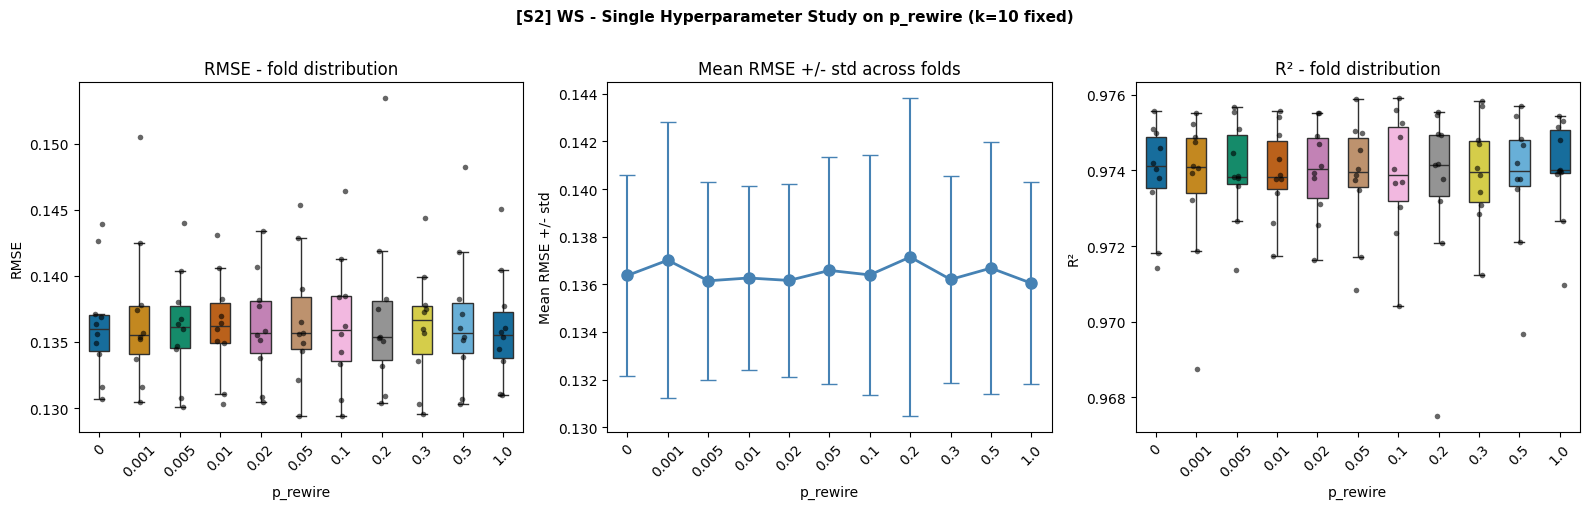


[BA] Sweeping edges-per-new-node m ...
    [scale_free] sweep 'm': 9 values x 10 folds = 90 evals
      [CLIP] m=1: sr_nat=2.389 -> 1.100
      [CLIP] m=2: sr_nat=2.942 -> 1.100
      [CLIP] m=4: sr_nat=3.940 -> 1.100
      [CLIP] m=8: sr_nat=5.851 -> 1.100
      [CLIP] m=16: sr_nat=6.740 -> 1.100
      [CLIP] m=32: sr_nat=8.486 -> 1.100
      [CLIP] m=64: sr_nat=11.039 -> 1.100
      [CLIP] m=128: sr_nat=13.422 -> 1.100
      [CLIP] m=256: sr_nat=11.202 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S2_ba_m.png


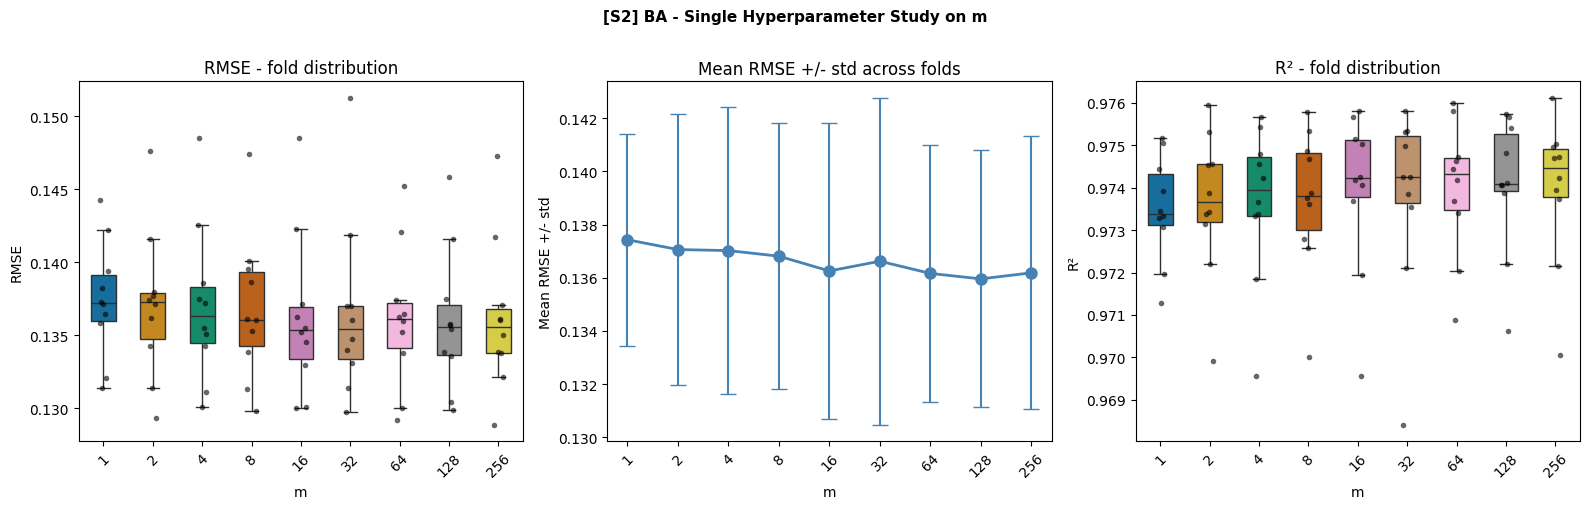


--------------------------------------------------------------
  Best ER  : p=0.4          -> mean RMSE = 0.13578
  Best WS  : k=16, p_rewire=1.0
              RMSE(k)=0.13579  RMSE(prw)=0.13605  best=0.13579
  Best BA  : m=128          -> mean RMSE = 0.13595
  Elapsed  : 2.1 min


In [10]:
study_results["S2"] = run_signal_study(
    "S2", SIGNALS["S2"], BEST_PARAMS_PER_SIGNAL["S2"],
    ER_P_VALUES, WS_K_VALUES, WS_PRW_VALUES, BA_M_VALUES,
    fixed_k=FIXED_K, fixed_p_rewire=FIXED_P_REWIRE,
)


## 6. Topology Study - Signal S3
**5 frequencies + beating pair (T=50 & T=53), sigma=0.22** - the near-harmonic
pair creates a slow implicit envelope with beat period ≈ 883 timesteps, so the
reservoir must preserve correlations much longer than in S1-S2.

Expected behaviour: architectures with richer recurrent structure should start to
separate more clearly here, especially if the topology helps long-range memory.



  S3 - 5 freq + beating, sigma=0.22
  Near-period pair T=50 & T=53 creates slow beating
  Dataset: X=(14990, 10)  y=(14990, 1)
  ESN params: {'N': 100, 'sr': 1.3, 'lr': 0.1, 'ridge': 0.05, 'washout': 10}

[ER] Sweeping connection probability p ...
    [random] sweep 'p': 11 values x 10 folds = 110 evals
      [CLIP] p=0.1: sr_nat=3.139 -> 1.100
      [CLIP] p=0.2: sr_nat=4.823 -> 1.100
      [CLIP] p=0.3: sr_nat=5.420 -> 1.100
      [CLIP] p=0.4: sr_nat=6.130 -> 1.100
      [CLIP] p=0.5: sr_nat=7.515 -> 1.100
      [CLIP] p=0.6: sr_nat=7.618 -> 1.100
      [CLIP] p=0.7: sr_nat=8.181 -> 1.100
      [CLIP] p=0.8: sr_nat=9.590 -> 1.100
      [CLIP] p=0.9: sr_nat=10.405 -> 1.100
      [CLIP] p=1.0: sr_nat=10.517 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S3_er_p.png


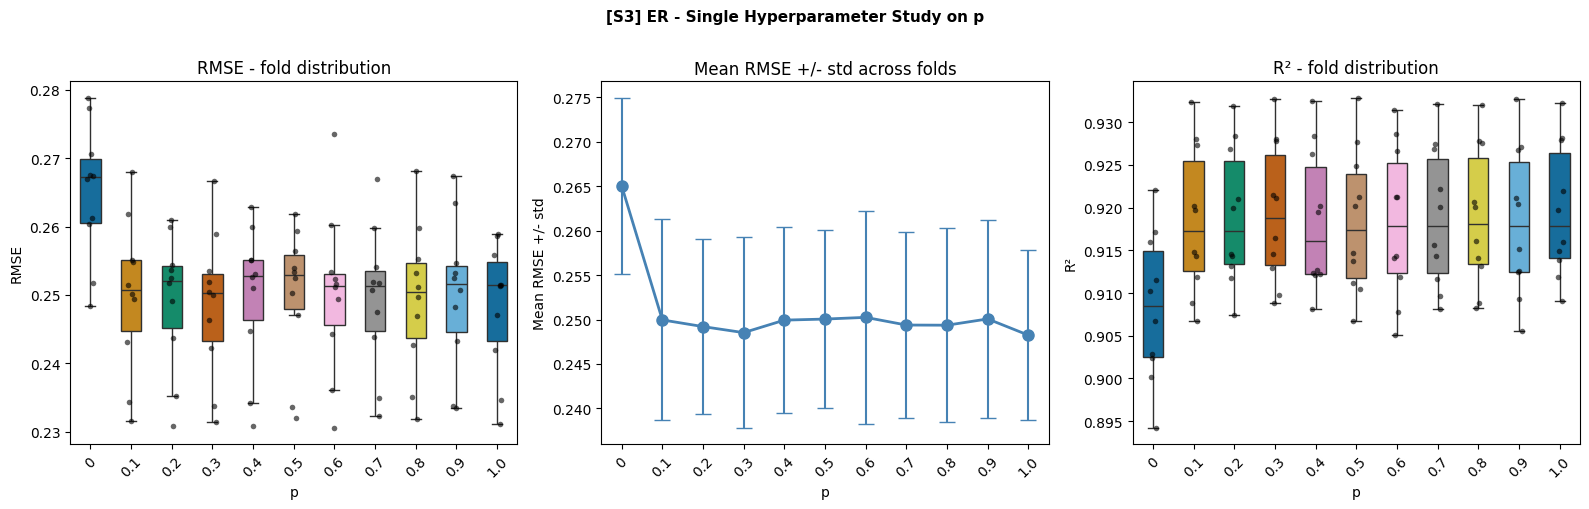


[WS] Sweeping mean degree k (p_rewire=0.3 fixed) ...
    [small_world] sweep 'k': 7 values x 10 folds = 70 evals
      [CLIP] k=2: sr_nat=2.319 -> 1.100
      [CLIP] k=4: sr_nat=2.781 -> 1.100
      [CLIP] k=8: sr_nat=3.830 -> 1.100
      [CLIP] k=16: sr_nat=4.804 -> 1.100
      [CLIP] k=32: sr_nat=6.219 -> 1.100
      [CLIP] k=64: sr_nat=8.200 -> 1.100
      [CLIP] k=98: sr_nat=10.877 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S3_ws_k.png


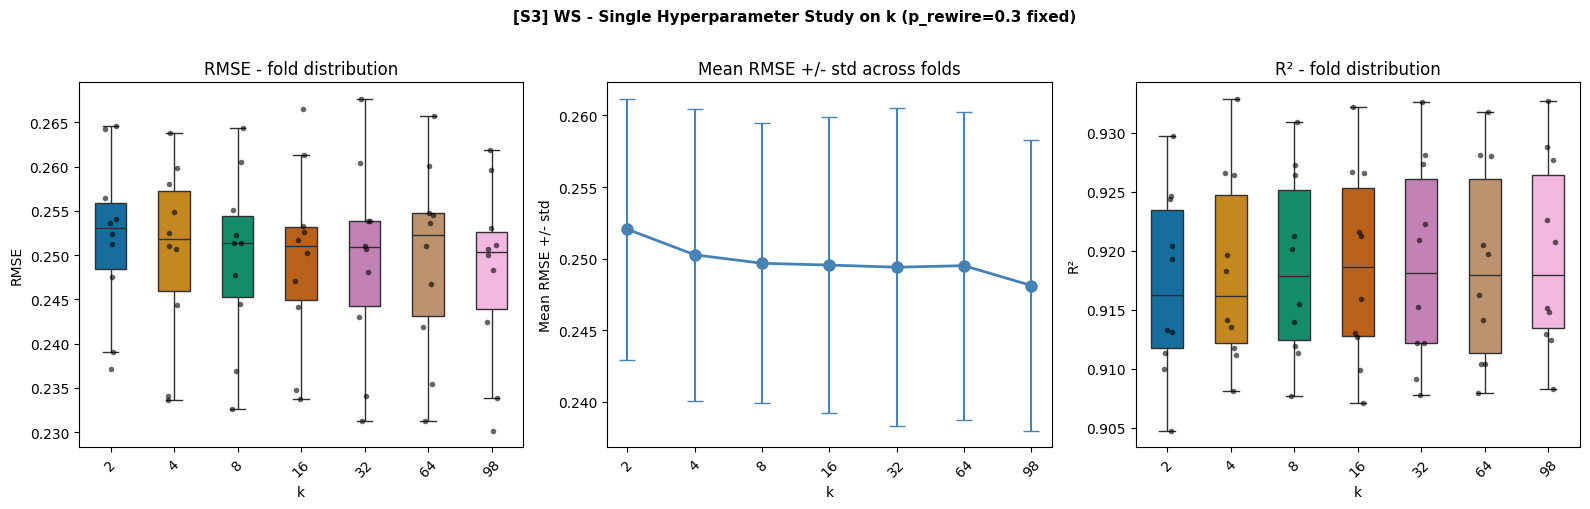


[WS] Sweeping rewiring prob p_rewire (k=10 fixed) ...
    [small_world] sweep 'p_rewire': 11 values x 10 folds = 110 evals
      [CLIP] p_rewire=0: sr_nat=3.962 -> 1.100
      [CLIP] p_rewire=0.001: sr_nat=3.700 -> 1.100
      [CLIP] p_rewire=0.005: sr_nat=3.704 -> 1.100
      [CLIP] p_rewire=0.01: sr_nat=3.745 -> 1.100
      [CLIP] p_rewire=0.02: sr_nat=4.419 -> 1.100
      [CLIP] p_rewire=0.05: sr_nat=3.757 -> 1.100
      [CLIP] p_rewire=0.1: sr_nat=4.248 -> 1.100
      [CLIP] p_rewire=0.2: sr_nat=3.269 -> 1.100
      [CLIP] p_rewire=0.3: sr_nat=4.214 -> 1.100
      [CLIP] p_rewire=0.5: sr_nat=3.400 -> 1.100
      [CLIP] p_rewire=1.0: sr_nat=3.571 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S3_ws_prw.png


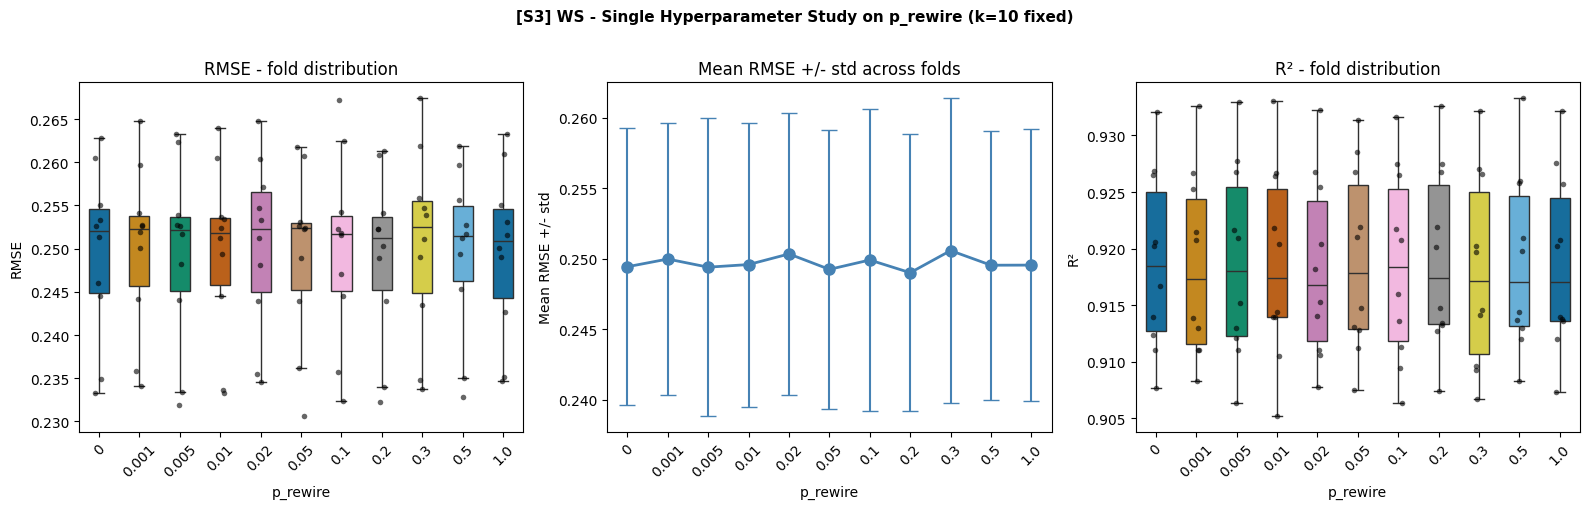


[BA] Sweeping edges-per-new-node m ...
    [scale_free] sweep 'm': 8 values x 10 folds = 80 evals
      [CLIP] m=1: sr_nat=2.707 -> 1.100
      [CLIP] m=2: sr_nat=3.681 -> 1.100
      [CLIP] m=4: sr_nat=3.974 -> 1.100
      [CLIP] m=8: sr_nat=4.272 -> 1.100
      [CLIP] m=16: sr_nat=6.194 -> 1.100
      [CLIP] m=32: sr_nat=7.020 -> 1.100
      [CLIP] m=64: sr_nat=8.106 -> 1.100
      [CLIP] m=99: sr_nat=3.295 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S3_ba_m.png


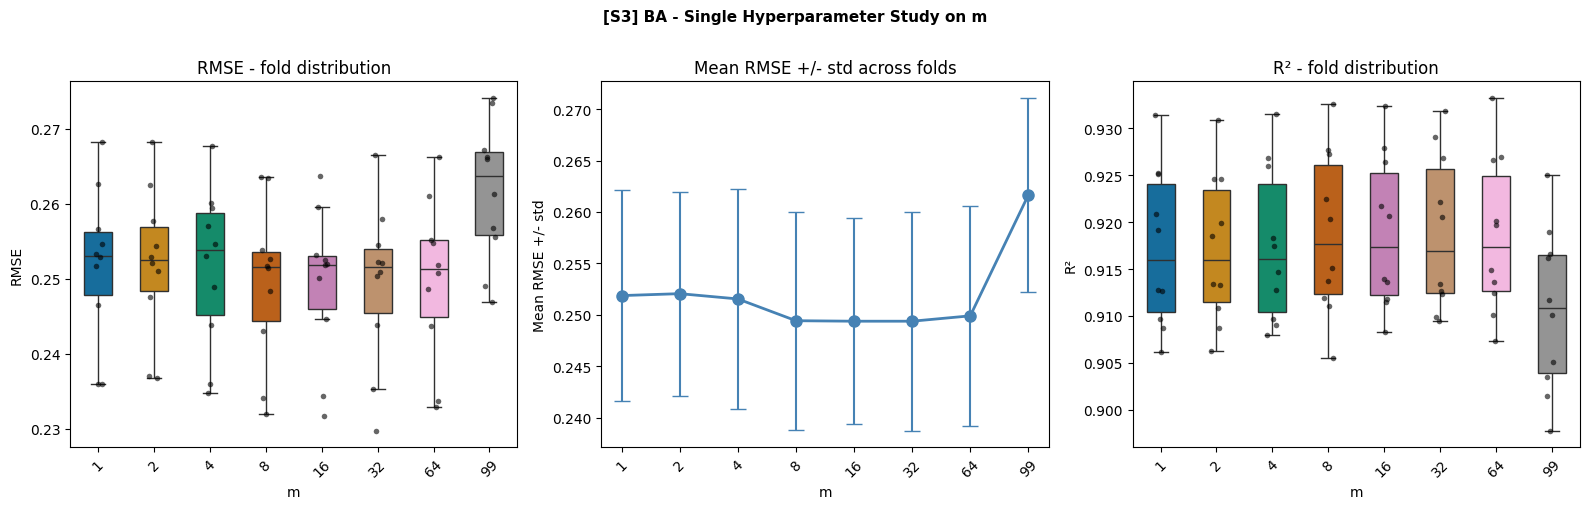


--------------------------------------------------------------
  Best ER  : p=1.0          -> mean RMSE = 0.24824
  Best WS  : k=98, p_rewire=0.2
              RMSE(k)=0.24813  RMSE(prw)=0.24902  best=0.24813
  Best BA  : m=16          -> mean RMSE = 0.24937
  Elapsed  : 1.0 min


In [11]:
study_results["S3"] = run_signal_study(
    "S3", SIGNALS["S3"], BEST_PARAMS_PER_SIGNAL["S3"],
    ER_P_VALUES, WS_K_VALUES, WS_PRW_VALUES, BA_M_VALUES,
    fixed_k=FIXED_K, fixed_p_rewire=FIXED_P_REWIRE,
)


## 7. Topology Study - Signal S4
**6 frequencies + slow amplitude modulation (T_AM=5000), sigma=0.38** - the task
is now both spectrally richer and mildly non-stationary, because a slow sinusoidal
envelope modulates the overall signal amplitude.

Expected behaviour: the AM creates a qualitative shift from pure periodic tracking
to periodic tracking under changing gain, so inter-architecture gaps should become
clearer than in S1-S3.



  S4 - 6 freq + AM, sigma=0.38
  Slow amplitude modulation (T_AM=5000)
  Dataset: X=(14990, 10)  y=(14990, 1)
  ESN params: {'N': 100, 'sr': 0.9, 'lr': 0.1, 'ridge': 0.05, 'washout': 10}

[ER] Sweeping connection probability p ...
    [random] sweep 'p': 11 values x 10 folds = 110 evals
      [CLIP] p=0.1: sr_nat=3.297 -> 1.100
      [CLIP] p=0.2: sr_nat=4.583 -> 1.100
      [CLIP] p=0.3: sr_nat=6.373 -> 1.100
      [CLIP] p=0.4: sr_nat=6.650 -> 1.100
      [CLIP] p=0.5: sr_nat=7.401 -> 1.100
      [CLIP] p=0.6: sr_nat=8.483 -> 1.100
      [CLIP] p=0.7: sr_nat=8.887 -> 1.100
      [CLIP] p=0.8: sr_nat=9.998 -> 1.100
      [CLIP] p=0.9: sr_nat=9.581 -> 1.100
      [CLIP] p=1.0: sr_nat=11.122 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S4_er_p.png


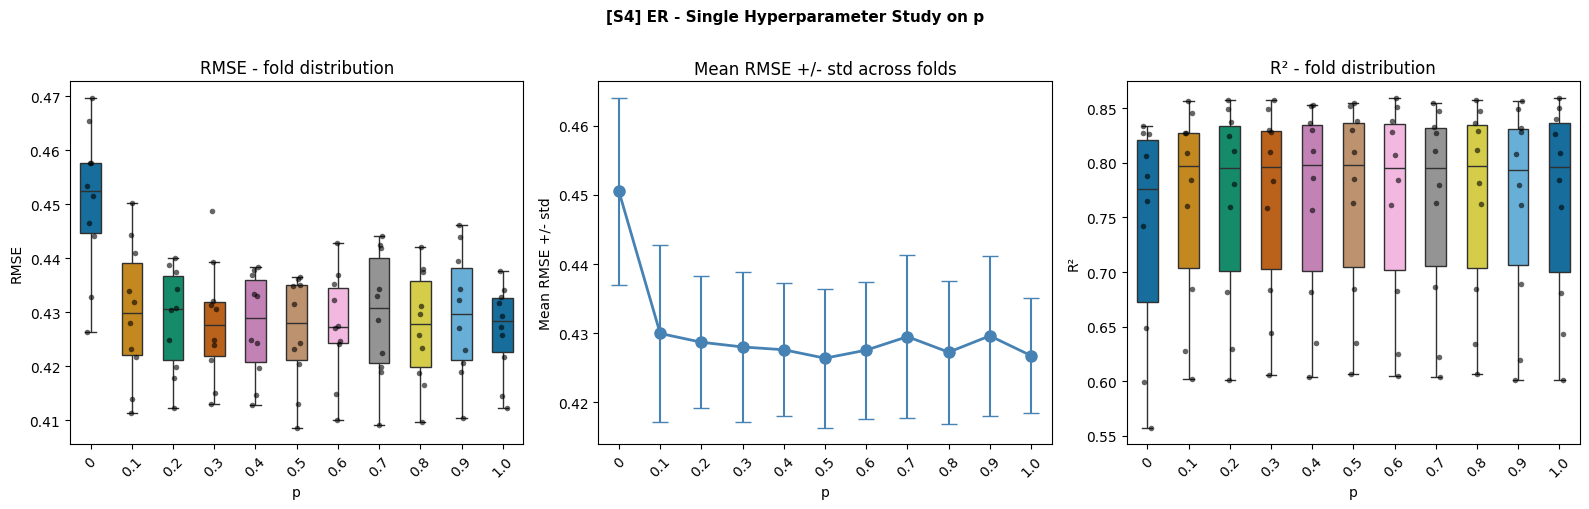


[WS] Sweeping mean degree k (p_rewire=0.3 fixed) ...
    [small_world] sweep 'k': 7 values x 10 folds = 70 evals
      [CLIP] k=2: sr_nat=2.588 -> 1.100
      [CLIP] k=4: sr_nat=2.409 -> 1.100
      [CLIP] k=8: sr_nat=3.261 -> 1.100
      [CLIP] k=16: sr_nat=4.120 -> 1.100
      [CLIP] k=32: sr_nat=5.880 -> 1.100
      [CLIP] k=64: sr_nat=8.573 -> 1.100
      [CLIP] k=98: sr_nat=10.668 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S4_ws_k.png


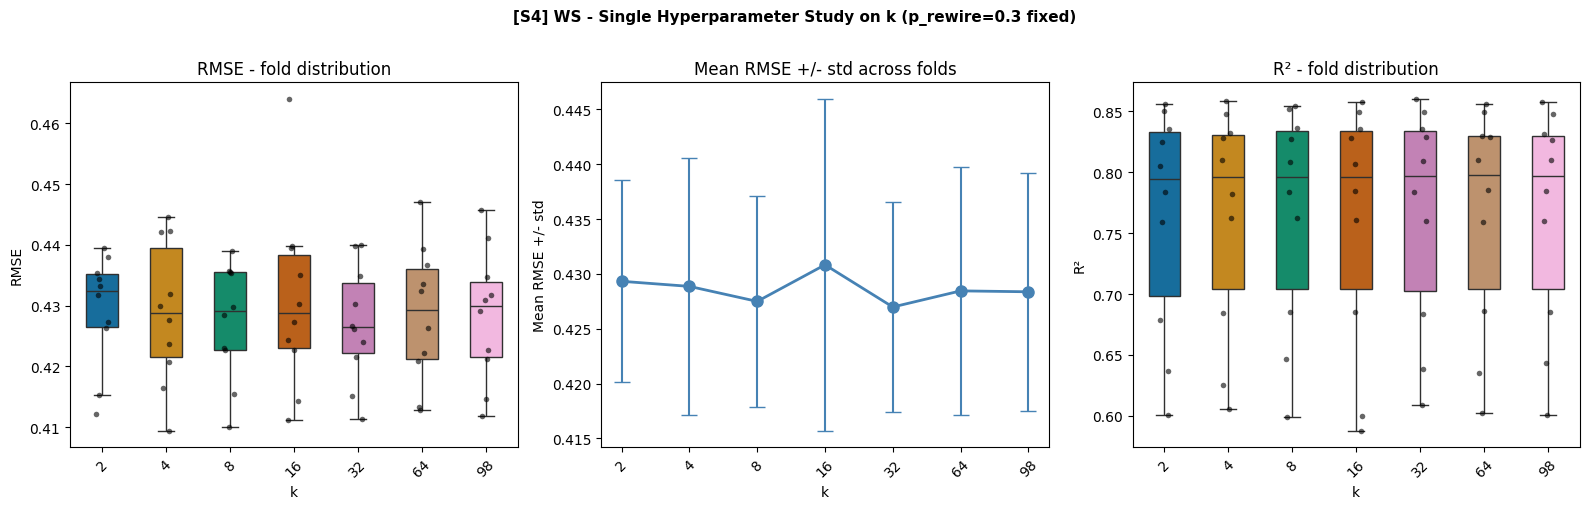


[WS] Sweeping rewiring prob p_rewire (k=10 fixed) ...
    [small_world] sweep 'p_rewire': 11 values x 10 folds = 110 evals
      [CLIP] p_rewire=0: sr_nat=4.677 -> 1.100
      [CLIP] p_rewire=0.001: sr_nat=3.683 -> 1.100
      [CLIP] p_rewire=0.005: sr_nat=4.005 -> 1.100
      [CLIP] p_rewire=0.01: sr_nat=3.700 -> 1.100
      [CLIP] p_rewire=0.02: sr_nat=3.661 -> 1.100
      [CLIP] p_rewire=0.05: sr_nat=3.995 -> 1.100
      [CLIP] p_rewire=0.1: sr_nat=3.703 -> 1.100
      [CLIP] p_rewire=0.2: sr_nat=3.662 -> 1.100
      [CLIP] p_rewire=0.3: sr_nat=3.676 -> 1.100
      [CLIP] p_rewire=0.5: sr_nat=3.481 -> 1.100
      [CLIP] p_rewire=1.0: sr_nat=3.599 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S4_ws_prw.png


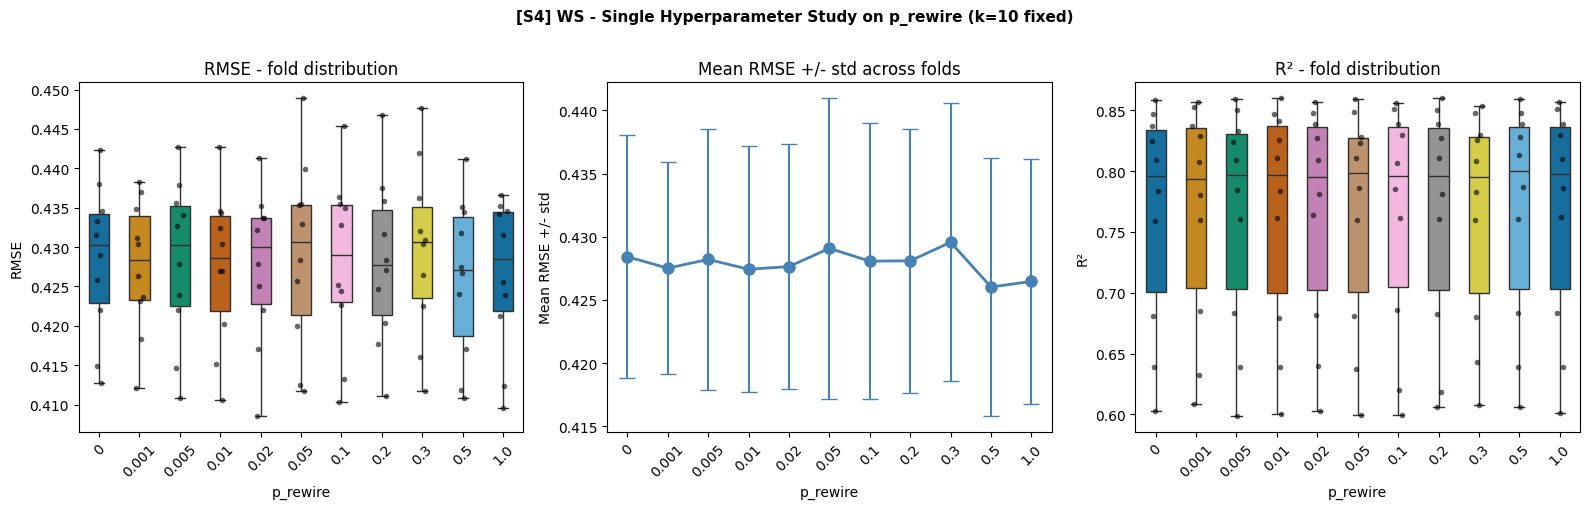


[BA] Sweeping edges-per-new-node m ...
    [scale_free] sweep 'm': 8 values x 10 folds = 80 evals
      [CLIP] m=1: sr_nat=3.068 -> 1.100
      [CLIP] m=2: sr_nat=3.234 -> 1.100
      [CLIP] m=4: sr_nat=3.536 -> 1.100
      [CLIP] m=8: sr_nat=4.589 -> 1.100
      [CLIP] m=16: sr_nat=6.470 -> 1.100
      [CLIP] m=32: sr_nat=7.459 -> 1.100
      [CLIP] m=64: sr_nat=8.263 -> 1.100
      [CLIP] m=99: sr_nat=1.117 -> 1.100
    Figure saved -> single_hp_outputs_3/shs_S4_ba_m.png


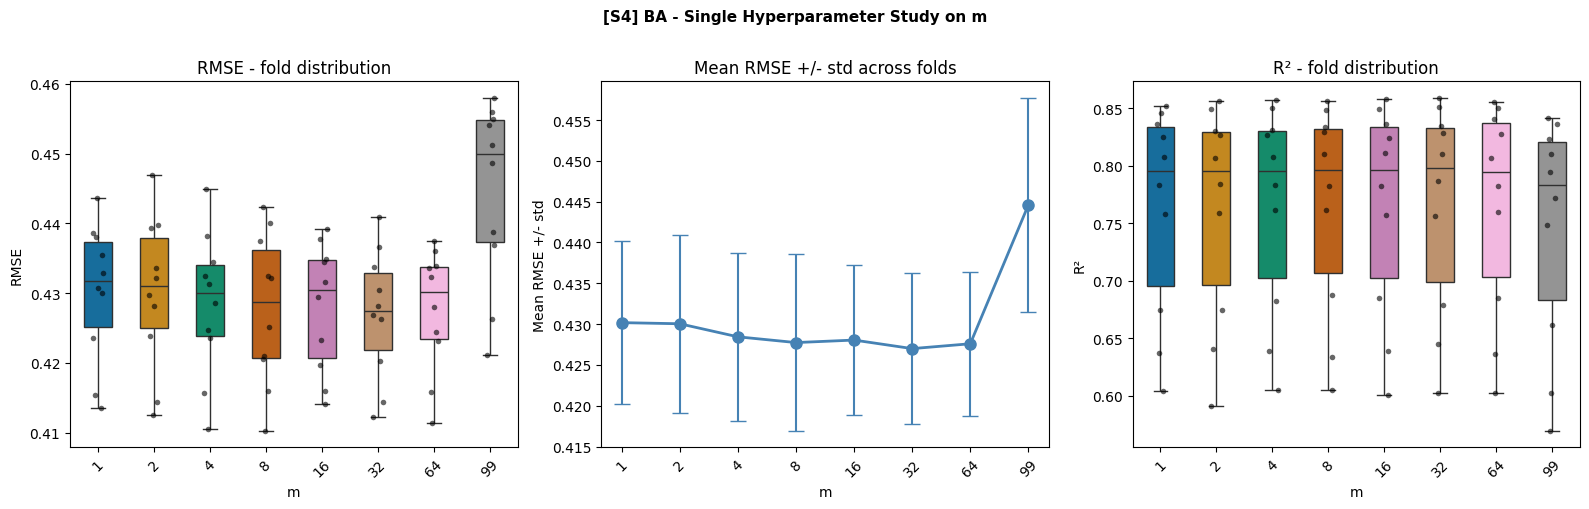


--------------------------------------------------------------
  Best ER  : p=0.5          -> mean RMSE = 0.42637
  Best WS  : k=32, p_rewire=0.5
              RMSE(k)=0.42699  RMSE(prw)=0.42602  best=0.42602
  Best BA  : m=32          -> mean RMSE = 0.42700
  Elapsed  : 1.0 min


In [12]:
study_results["S4"] = run_signal_study(
    "S4", SIGNALS["S4"], BEST_PARAMS_PER_SIGNAL["S4"],
    ER_P_VALUES, WS_K_VALUES, WS_PRW_VALUES, BA_M_VALUES,
    fixed_k=FIXED_K, fixed_p_rewire=FIXED_P_REWIRE,
)


## 8. Cross-Signal Architecture Comparison Grid

This section collects the results from all four signal studies and builds the
comparison grid requested by the research objective:

1. **Summary table** - best RMSE and best structural parameter per (signal x architecture)
2. **Heatmap** - best RMSE as a function of signal difficulty x architecture
3. **SHS overlay** - sensitivity curves for each architecture, one plot per architecture
   overlaying all four signals to show how sensitivity shifts with complexity
4. **Best prediction plots** - qualitative comparison of real vs predicted signal
   for each (signal x architecture) at the best structural setting

In [13]:
# ---------------------------------------------------------------------------
# 8.1 Summary table - best RMSE and best param per (signal x architecture)
# ---------------------------------------------------------------------------
rows = []
for sig_name, res in study_results.items():
    esn_params = res["esn_params"]
    rows.append({
        "Signal": sig_name,
        "Label": res["label"],
        "n_freq": res["n_components"],
        "noise_sigma": res["noise_std"],
        "Extra": res["extra"],
        "Best N": esn_params["N"],
        "Best sr": esn_params["sr"],
        "Best lr": esn_params["lr"],
        "Best ridge": esn_params["ridge"],
        "Best washout": esn_params["washout"],
        "ER best p": res["ER"]["best_p"],
        "ER RMSE": res["ER"]["best_rmse"],
        "WS best k": res["WS_k"]["best_k"],
        "WS best prw": res["WS_p"]["best_prw"],
        "WS RMSE": res["WS_best_rmse"],
        "BA best m": res["BA"]["best_m"],
        "BA RMSE": res["BA"]["best_rmse"],
    })

df_summary = pd.DataFrame(rows).set_index("Signal")

print("Best RMSE per signal x architecture\n")
cols_show = [
    "Label", "n_freq", "noise_sigma",
    "Best N", "Best sr", "Best lr", "Best ridge", "Best washout",
    "ER best p", "ER RMSE", "WS best k", "WS best prw", "WS RMSE", "BA best m", "BA RMSE",
]
print(df_summary[cols_show].to_string(float_format="%.5f"))

df_summary.to_csv("single_hp_outputs_3/summary_best_rmse.csv")
print("\nSaved -> single_hp_outputs_3/summary_best_rmse.csv")


Best RMSE per signal x architecture

                                    Label  n_freq  noise_sigma  Best N  Best sr  Best lr  Best ridge  Best washout  ER best p  ER RMSE  WS best k  WS best prw  WS RMSE  BA best m  BA RMSE
Signal                                                                                                                                                                                     
S1          S1 - NB1 baseline, sigma=0.05       3      0.05000     400  1.30000  0.05000     0.05000            10    0.20000  0.05501         64      0.50000  0.05496        128  0.05522
S2                S2 - 4 freq, sigma=0.12       4      0.12000     300  1.30000  0.10000     0.05000            10    0.40000  0.13578         16      1.00000  0.13579        128  0.13595
S3      S3 - 5 freq + beating, sigma=0.22       5      0.22000     100  1.30000  0.10000     0.05000            10    1.00000  0.24824         98      0.20000  0.24813         16  0.24937
S4           S4 - 6 fre

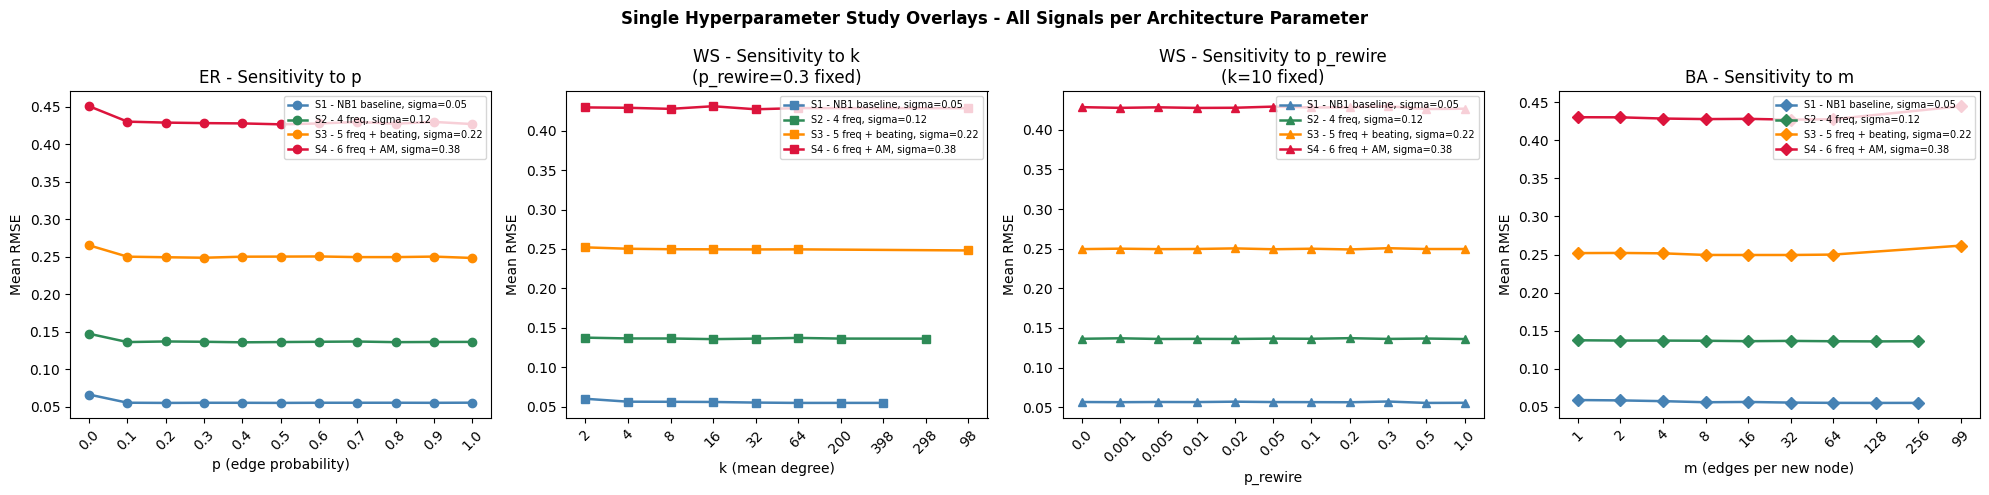

Figure saved → single_hp_outputs_3/comparison_shs_overlays.png


In [ ]:
# ---------------------------------------------------------------------------
# 8.3 SHS overlay - one subplot per architecture, all signals overlaid
# Shows how parameter sensitivity shifts as signal difficulty increases.
# ---------------------------------------------------------------------------
sig_colors  = ["steelblue", "seagreen", "darkorange", "crimson",
               "purple", "brown", "pink", "gray", "olive", "cyan"]
sig_names   = list(study_results.keys())

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Single Hyperparameter Study Overlays - All Signals per Architecture Parameter",
             fontsize=12, fontweight="bold")

# ── ER: p ──
ax = axes[0]
for color, sig in zip(sig_colors, sig_names):
    df = study_results[sig]["ER"]["df"]
    agg = df.dropna(subset=["rmse"]).groupby("p")["rmse"].mean()
    ax.plot(agg.index.astype(str), agg.values, marker="o", color=color,
            label=study_results[sig]["label"], linewidth=1.8)
ax.set_title("ER - Sensitivity to p")
ax.set_xlabel("p (edge probability)")
ax.set_ylabel("Mean RMSE")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=7)

# ── WS: k ──
ax = axes[1]
for color, sig in zip(sig_colors, sig_names):
    df = study_results[sig]["WS_k"]["df"]
    agg = df.dropna(subset=["rmse"]).groupby("k")["rmse"].mean()
    ax.plot(agg.index.astype(str), agg.values, marker="s", color=color,
            label=study_results[sig]["label"], linewidth=1.8)
ax.set_title(f"WS - Sensitivity to k\n(p_rewire={FIXED_P_REWIRE} fixed)")
ax.set_xlabel("k (mean degree)")
ax.set_ylabel("Mean RMSE")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=7)

# ── WS: p_rewire ──
ax = axes[2]
for color, sig in zip(sig_colors, sig_names):
    df = study_results[sig]["WS_p"]["df"]
    agg = df.dropna(subset=["rmse"]).groupby("p_rewire")["rmse"].mean()
    ax.plot(agg.index.astype(str), agg.values, marker="^", color=color,
            label=study_results[sig]["label"], linewidth=1.8)
ax.set_title(f"WS - Sensitivity to p_rewire\n(k={FIXED_K} fixed)")
ax.set_xlabel("p_rewire")
ax.set_ylabel("Mean RMSE")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=7)

# ── BA: m ──
ax = axes[3]
for color, sig in zip(sig_colors, sig_names):
    df = study_results[sig]["BA"]["df"]
    agg = df.dropna(subset=["rmse"]).groupby("m")["rmse"].mean()
    ax.plot(agg.index.astype(str), agg.values, marker="D", color=color,
            label=study_results[sig]["label"], linewidth=1.8)
ax.set_title("BA - Sensitivity to m")
ax.set_xlabel("m (edges per new node)")
ax.set_ylabel("Mean RMSE")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("single_hp_outputs_3/comparison_shs_overlays.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figure saved -> single_hp_outputs_3/comparison_shs_overlays.png")

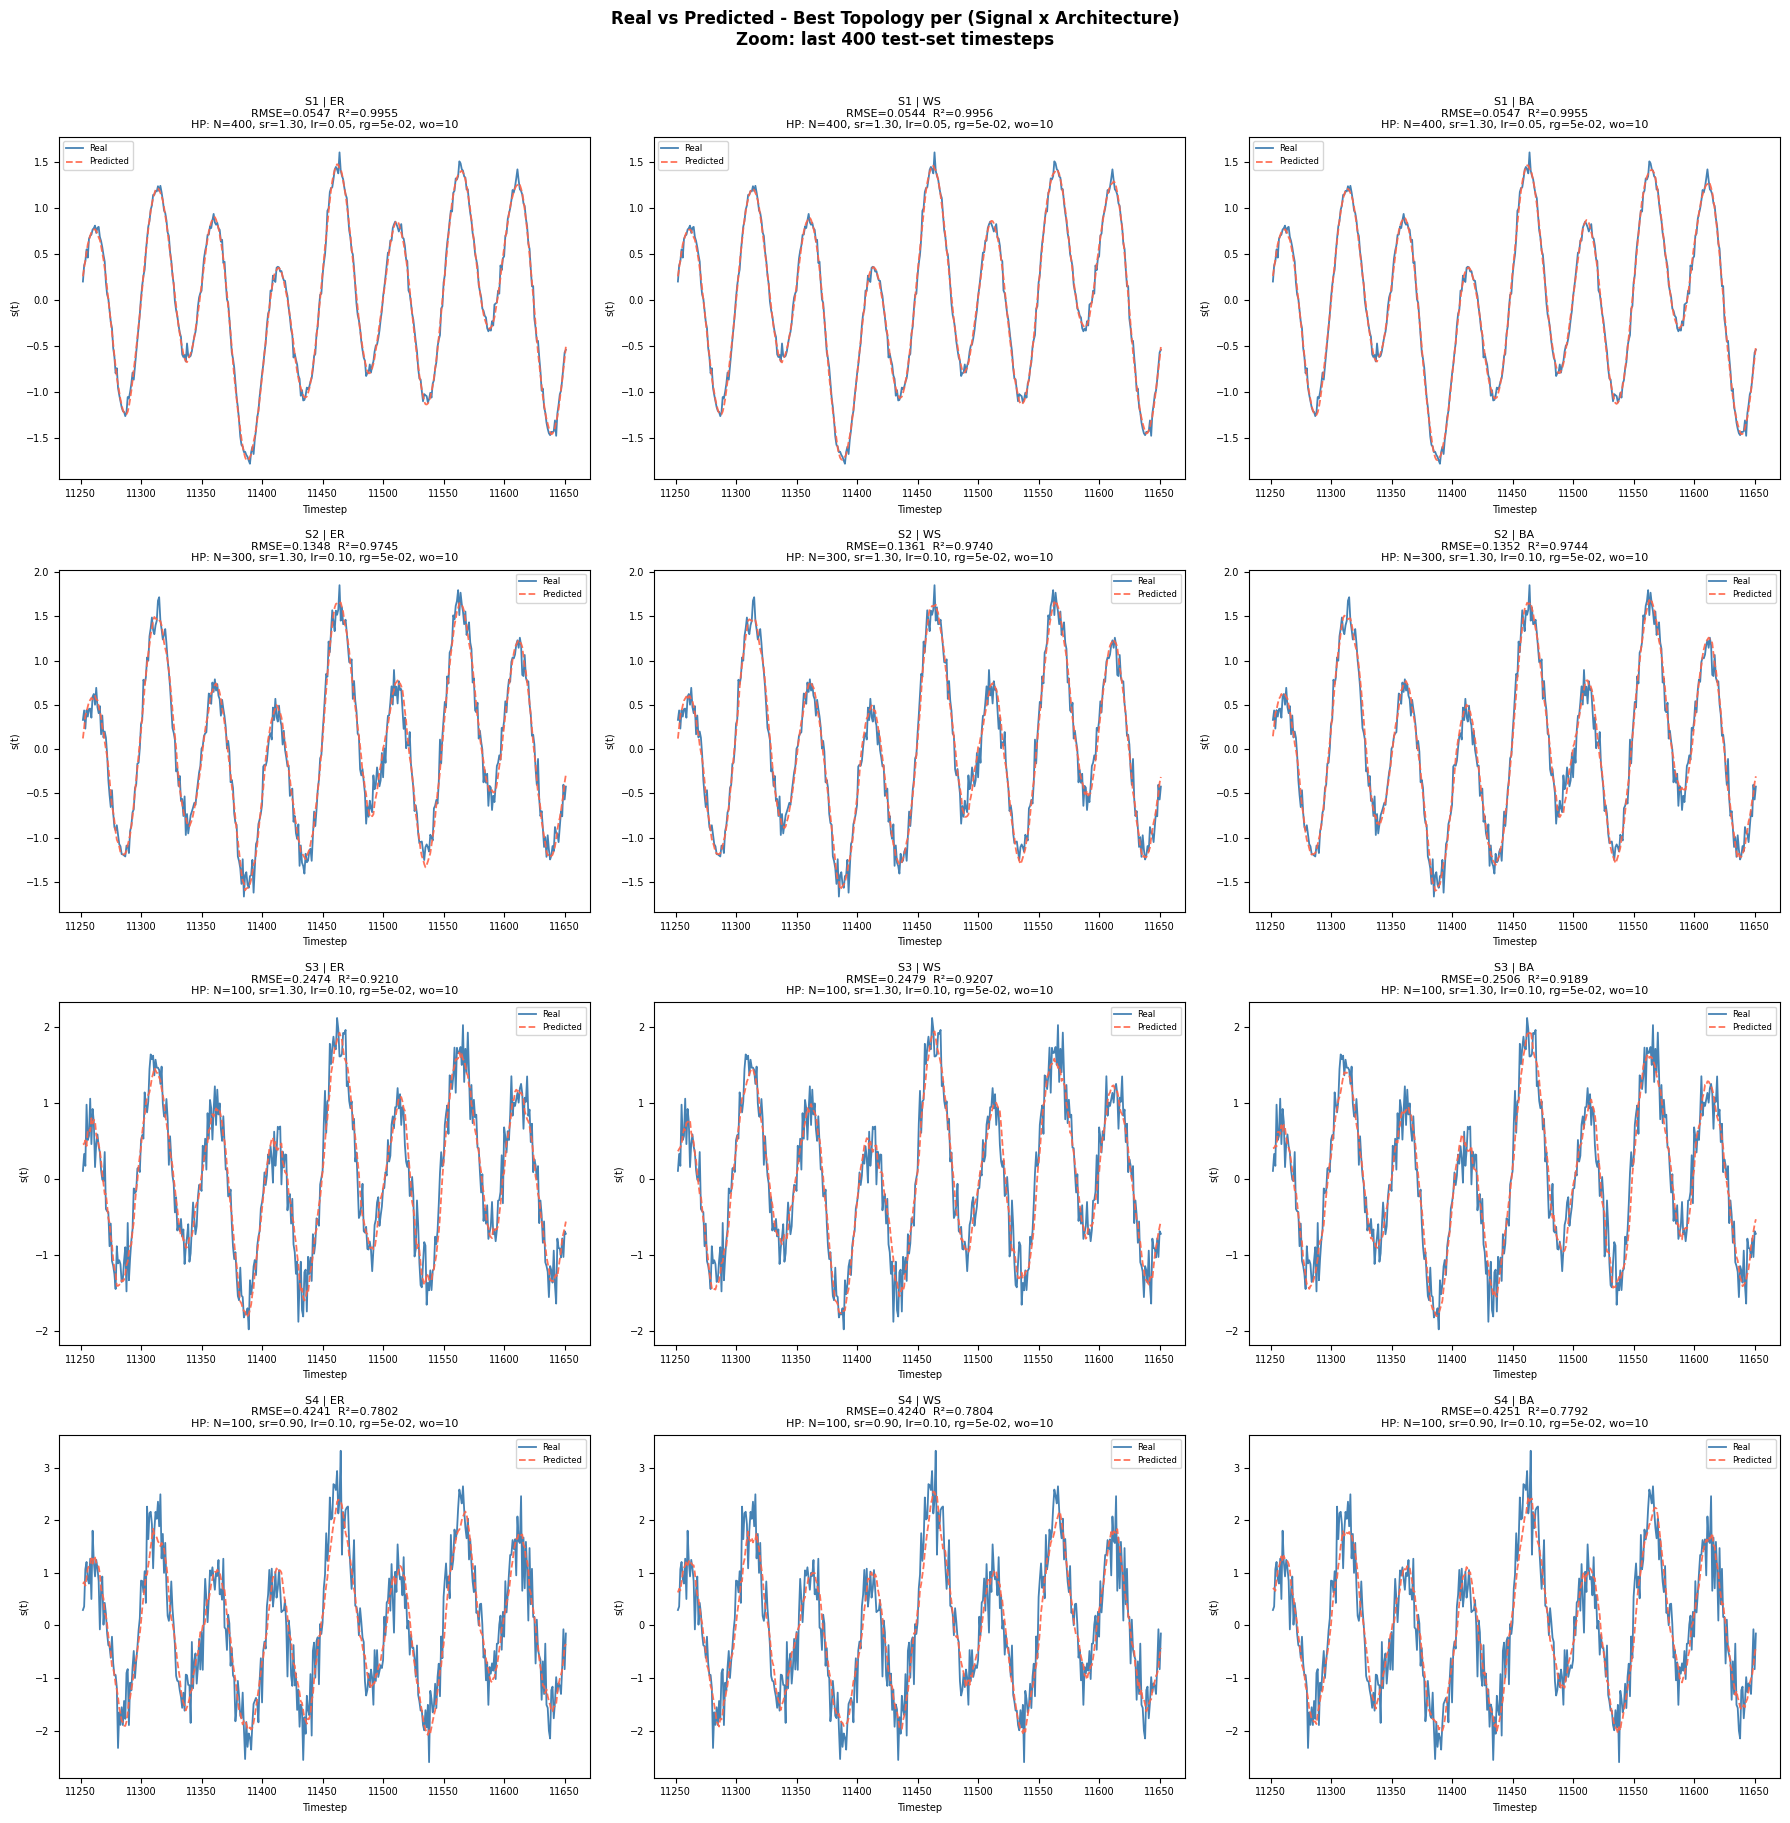

Figure saved -> single_hp_outputs_3/prediction_grid.png


In [15]:
# ---------------------------------------------------------------------------
# 8.4 Prediction grid - best topology per (signal x architecture)
# N rows (signals) x 3 columns (architectures), each showing zoom of test set
# ---------------------------------------------------------------------------
arch_configs = [
    ("ER", "random", lambda res: {"p": res["ER"]["best_p"]}),
    ("WS", "small_world", lambda res: {"k": res["WS_k"]["best_k"], "p_rewire": res["WS_p"]["best_prw"]}),
    ("BA", "scale_free", lambda res: {"m": res["BA"]["best_m"]}),
]

fig, axes = plt.subplots(len(sig_names), len(arch_configs), figsize=(18, 4.5 * len(sig_names)))
fig.suptitle(
    "Real vs Predicted - Best Topology per (Signal x Architecture)\n"
    "Zoom: last 400 test-set timesteps",
    fontsize=12, fontweight="bold", y=1.01
)

for row, sig_name in enumerate(sig_names):
    res = study_results[sig_name]
    sig_cfg = SIGNALS[sig_name]
    esn_params = res["esn_params"]
    signal = sig_cfg["data"]
    X_all_s, y_all_s = build_dataset(signal, lag=LAG)
    n = len(X_all_s)
    n_train = int(n * 0.75)
    X_te_s, y_te_s = X_all_s[n_train:], y_all_s[n_train:]
    t_test = np.arange(len(signal))[LAG + n_train:]
    zoom = 400

    for col, (arch_name, topo_str, get_params) in enumerate(arch_configs):
        ax = axes[row, col]
        topo_params = get_params(res)

        try:
            W, _ = make_reservoir_matrix(esn_params["N"], topo_str, topo_params)
            scaler = StandardScaler()
            X_tr_all = scaler.fit_transform(X_all_s[:n_train])
            X_te_all = scaler.transform(X_te_s)
            reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
            model = reservoir >> Ridge(ridge=esn_params["ridge"])
            model.fit(X_tr_all, y_all_s[:n_train], warmup=int(esn_params["washout"]))
            y_pred = np.array(model.run(X_te_all)).reshape(-1)
            y_true = y_te_s.ravel()
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            r2 = r2_score(y_true, y_pred)

            ax.plot(t_test[:zoom], y_true[:zoom], lw=1.3, color="steelblue", label="Real")
            ax.plot(t_test[:zoom], y_pred[:zoom], lw=1.3, color="tomato", ls="--", alpha=0.9, label="Predicted")
            ax.set_title(
                f"{sig_name} | {arch_name}\n"
                f"RMSE={rmse:.4f}  R²={r2:.4f}\n"
                f"HP: N={esn_params['N']}, sr={esn_params['sr']:.2f}, lr={esn_params['lr']:.2f}, "
                f"rg={esn_params['ridge']:.0e}, wo={esn_params['washout']}",
                fontsize=8,
            )
        except Exception as exc:
            ax.text(0.5, 0.5, f"Error:\n{exc}", transform=ax.transAxes,
                    ha="center", va="center", fontsize=7, color="red")
            ax.set_title(f"{sig_name} | {arch_name}", fontsize=8)

        ax.set_xlabel("Timestep", fontsize=7)
        ax.set_ylabel("s(t)", fontsize=7)
        ax.legend(fontsize=6)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("single_hp_outputs_3/prediction_grid.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved -> single_hp_outputs_3/prediction_grid.png")


In [ ]:
# ---------------------------------------------------------------------------
# 8.5 Architecture ranking - how often each topology wins across signals
# ---------------------------------------------------------------------------
print("Architecture ranking (best RMSE wins per signal)\n")
print(f"{'Signal':<40}  {'Winner':<18}  RMSE")
print("─" * 65)

wins = {"ER": 0, "WS": 0, "BA": 0}
for sig in sig_names:
    res = study_results[sig]
    rmse_dict = {
        "ER":  res["ER"]["best_rmse"],
        "WS":  res["WS_best_rmse"],
        "BA":  res["BA"]["best_rmse"],
    }
    winner = min(rmse_dict, key=rmse_dict.get)
    wins[winner] += 1
    label = res["label"]
    print(f"  {label:<38}  {winner:<18}  {rmse_dict[winner]:.5f}")

print("─" * 65)
print(f"  Wins:  ER={wins['ER']}  WS={wins['WS']}  BA={wins['BA']}")

# Relative degradation from S1 to S4
print("\nRelative RMSE degradation S1 -> S4:")
for arch, key in [("ER", "ER"), ("WS", "WS_best_rmse" if False else None), ("BA", "BA")]:
    rmse_s1 = study_results["S1"][key]["best_rmse"] if key else study_results["S1"]["WS_best_rmse"]
    rmse_s4 = study_results["S4"][key]["best_rmse"] if key else study_results["S4"]["WS_best_rmse"]
    if arch == "WS":
        rmse_s1 = study_results["S1"]["WS_best_rmse"]
        rmse_s4 = study_results["S4"]["WS_best_rmse"]
    pct = 100.0 * (rmse_s4 - rmse_s1) / rmse_s1
    print(f"  {arch}: {rmse_s1:.5f} -> {rmse_s4:.5f}  (+{pct:.1f}%)")

Architecture ranking (best RMSE wins per signal)

Signal                                    Winner              RMSE
─────────────────────────────────────────────────────────────────
  S1 - NB1 baseline, sigma=0.05           WS                  0.05496
  S2 - 4 freq, sigma=0.12                 ER                  0.13578
  S3 - 5 freq + beating, sigma=0.22       WS                  0.24813
  S4 - 6 freq + AM, sigma=0.38            WS                  0.42602
─────────────────────────────────────────────────────────────────
  Wins:  ER=1  WS=3  BA=0

Relative RMSE degradation S1 → S4:
  ER: 0.05501 → 0.42637  (+675.1%)
  WS: 0.05496 → 0.42602  (+675.2%)
  BA: 0.05522 → 0.42700  (+673.3%)


## 9. Final Comparison — Mean RMSE vs. Signal Difficulty

Using the **canonical best topology parameters** fixed in Section 3.3, we evaluate
all three architectures on the **original ten-signal suite only**.

Unlike the previous version, there are no extra `S11-S20` signals here. Instead,
each of `S1-S10` uses its own **optimised ESN hyperparameters**, and the final
figure adds a compact bottom table listing the best `(N, sr, lr, ridge, washout)`
for every signal.

- **x-axis** — signal difficulty rank (`S1` ... `S10`), with labels showing the number
  of sine components and the noise level `sigma`
- **top panel** — mean RMSE across 10 CV folds for ER, WS, and BA (`+/- 1 std` shaded band)
- **middle panel** — architecture spread (`worst RMSE - best RMSE`)
- **bottom panel** — per-signal optimised ESN hyperparameters


Evaluating canonical topologies across 10 optimised signals (10-fold CV) ...

S1: ESN params = {'N': 400, 'sr': 1.3, 'lr': 0.05, 'ridge': 0.05, 'washout': 10}
  [ER] mean RMSE = 0.05506 +/- 0.00140
  [WS] mean RMSE = 0.05514 +/- 0.00137
  [BA] mean RMSE = 0.05550 +/- 0.00147

S2: ESN params = {'N': 300, 'sr': 1.3, 'lr': 0.1, 'ridge': 0.05, 'washout': 10}
  [ER] mean RMSE = 0.13659 +/- 0.00650
  [WS] mean RMSE = 0.13592 +/- 0.00519
  [BA] mean RMSE = 0.13604 +/- 0.00439

S3: ESN params = {'N': 100, 'sr': 1.3, 'lr': 0.1, 'ridge': 0.05, 'washout': 10}
  [ER] mean RMSE = 0.24952 +/- 0.00911
  [WS] mean RMSE = 0.25029 +/- 0.01038
  [BA] mean RMSE = 0.25033 +/- 0.00967

S4: ESN params = {'N': 100, 'sr': 0.9, 'lr': 0.1, 'ridge': 0.05, 'washout': 10}
  [ER] mean RMSE = 0.42905 +/- 0.01099
  [WS] mean RMSE = 0.42843 +/- 0.01064
  [BA] mean RMSE = 0.42971 +/- 0.01089

S5: ESN params = {'N': 100, 'sr': 0.9, 'lr': 0.1, 'ridge': 0.05, 'washout': 10}
  [ER] mean RMSE = 0.61537 +/- 0.01946
  [WS] mea

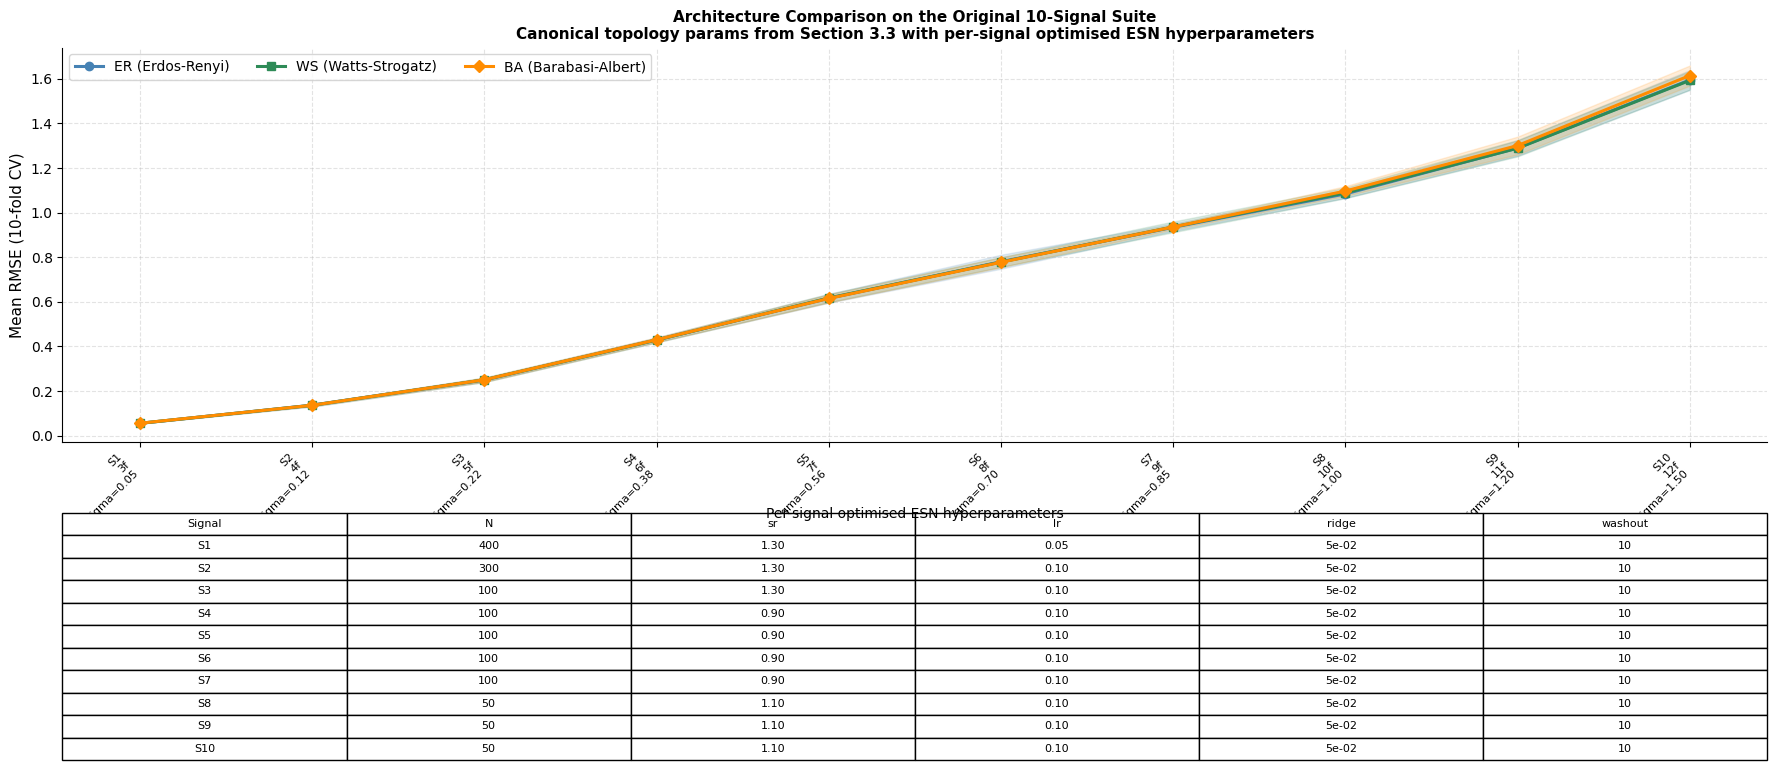

Figure saved -> single_hp_outputs_3/final_rmse_vs_difficulty.png
Saved -> single_hp_outputs_3/final_rmse_first10_summary.csv
Saved -> single_hp_outputs_3/final_rmse_extended_summary.csv

Final numeric summary

Signal  n_freq noise_sigma   N   sr   lr ridge  washout ER_mean  ER_std WS_mean  WS_std BA_mean  BA_std
    S1       3        0.05 400 1.30 0.05 5e-02       10 0.05506 0.00140 0.05514 0.00137 0.05550 0.00147
    S2       4        0.12 300 1.30 0.10 5e-02       10 0.13659 0.00650 0.13592 0.00519 0.13604 0.00439
    S3       5        0.22 100 1.30 0.10 5e-02       10 0.24952 0.00911 0.25029 0.01038 0.25033 0.00967
    S4       6        0.38 100 0.90 0.10 5e-02       10 0.42905 0.01099 0.42843 0.01064 0.42971 0.01089
    S5       7        0.56 100 0.90 0.10 5e-02       10 0.61537 0.01946 0.61708 0.01886 0.61499 0.01809
    S6       8        0.70 100 0.90 0.10 5e-02       10 0.77948 0.03135 0.77810 0.02192 0.77718 0.02253
    S7       9        0.85 100 0.90 0.10 5e-02       10 0.9338

In [18]:
# ---------------------------------------------------------------------------
# Final comparison on the 10 optimised signals
# ---------------------------------------------------------------------------
canonical_topo = {
    "ER": ("random", {"p": CANONICAL_ER_P}),
    "WS": ("small_world", {"k": CANONICAL_WS_K, "p_rewire": CANONICAL_WS_PRW}),
    "BA": ("scale_free", {"m": CANONICAL_BA_M}),
}

comparison_signals = {name: SIGNALS[name] for name in SIGNAL_ORDER}
results_final = {arch: {} for arch in canonical_topo}
tscv_final = TimeSeriesSplit(n_splits=N_SPLITS)

print(
    f"Evaluating canonical topologies across {len(comparison_signals)} optimised signals "
    f"({N_SPLITS}-fold CV) ...\n"
)

for sig_name, sig_cfg in comparison_signals.items():
    esn_params = BEST_PARAMS_PER_SIGNAL[sig_name]
    X_s, y_s = build_dataset(sig_cfg["data"], lag=LAG)
    print(f"{sig_name}: ESN params = {esn_params}")

    for arch_name, (topology, topo_params) in canonical_topo.items():
        fold_rmses = []
        W, info = make_reservoir_matrix(esn_params["N"], topology, topo_params)

        for train_idx, test_idx in tscv_final.split(X_s):
            X_tr_f, y_tr_f = X_s[train_idx], y_s[train_idx]
            X_te_f, y_te_f = X_s[test_idx], y_s[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr_f)
            X_te = scaler.transform(X_te_f)

            reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
            model = reservoir >> Ridge(ridge=esn_params["ridge"])
            model.fit(X_tr, y_tr_f, warmup=int(esn_params["washout"]))
            y_pred = np.array(model.run(X_te)).reshape(-1)
            fold_rmses.append(np.sqrt(mean_squared_error(y_te_f.ravel(), y_pred)))

        results_final[arch_name][sig_name] = {
            "mean": float(np.mean(fold_rmses)),
            "std": float(np.std(fold_rmses)),
            "folds": fold_rmses,
            "density": info["actual_density"],
        }
        print(
            f"  [{arch_name}] mean RMSE = {np.mean(fold_rmses):.5f} +/- {np.std(fold_rmses):.5f}"
        )
    print()

sig_order = list(comparison_signals.keys())
x_pos = np.arange(len(sig_order))
x_labels = [
    f"{sig}\n{comparison_signals[sig]['n_components']}f\nsigma={comparison_signals[sig]['noise_std']:.2f}"
    for sig in sig_order
]

arch_styles = {
    "ER": {"color": "steelblue", "marker": "o", "label": "ER (Erdos-Renyi)"},
    "WS": {"color": "seagreen", "marker": "s", "label": "WS (Watts-Strogatz)"},
    "BA": {"color": "darkorange", "marker": "D", "label": "BA (Barabasi-Albert)"},
}

fig = plt.figure(figsize=(22, 9))
gs = fig.add_gridspec(2, 1, height_ratios=[3.4, 1.8], hspace=0.30)
ax_main = fig.add_subplot(gs[0, 0])
ax_table = fig.add_subplot(gs[1, 0])
ax_table.axis("off")

for arch_name, style in arch_styles.items():
    means = [results_final[arch_name][sig]["mean"] for sig in sig_order]
    stds = [results_final[arch_name][sig]["std"] for sig in sig_order]

    ax_main.plot(
        x_pos, means,
        color=style["color"],
        marker=style["marker"],
        linewidth=2.2,
        markersize=6,
        label=style["label"],
    )
    ax_main.fill_between(
        x_pos,
        [m - sd for m, sd in zip(means, stds)],
        [m + sd for m, sd in zip(means, stds)],
        color=style["color"],
        alpha=0.15,
    )

ax_main.set_ylabel(f"Mean RMSE ({N_SPLITS}-fold CV)", fontsize=11)
ax_main.set_title(
    "Architecture Comparison on the Original 10-Signal Suite\n"
    "Canonical topology params from Section 3.3 with per-signal optimised ESN hyperparameters",
    fontsize=11,
    fontweight="bold",
)
ax_main.grid(True, linestyle="--", alpha=0.35)
ax_main.legend(fontsize=10, ncol=3, loc="upper left")
ax_main.set_xlabel("Signal difficulty rank (label = ID / sine count / noise sigma)", fontsize=11)
ax_main.set_xticks(x_pos)
ax_main.set_xticklabels(x_labels, fontsize=8, rotation=45, ha="right")

hp_rows = []
for sig in sig_order:
    p = BEST_PARAMS_PER_SIGNAL[sig]
    hp_rows.append([
        sig,
        p["N"],
        f"{p['sr']:.2f}",
        f"{p['lr']:.2f}",
        f"{p['ridge']:.0e}",
        p["washout"],
    ])

table = ax_table.table(
    cellText=hp_rows,
    colLabels=["Signal", "N", "sr", "lr", "ridge", "washout"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.0, 1.35)
ax_table.set_title("Per-signal optimised ESN hyperparameters", fontsize=10, pad=10)

sns.despine(ax=ax_main)
plt.tight_layout()
plt.savefig("single_hp_outputs_3/final_rmse_vs_difficulty.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figure saved -> single_hp_outputs_3/final_rmse_vs_difficulty.png")

summary_rows = []
for sig in sig_order:
    p = BEST_PARAMS_PER_SIGNAL[sig]
    summary_rows.append({
        "Signal": sig,
        "n_freq": comparison_signals[sig]["n_components"],
        "noise_sigma": comparison_signals[sig]["noise_std"],
        "N": p["N"],
        "sr": p["sr"],
        "lr": p["lr"],
        "ridge": p["ridge"],
        "washout": p["washout"],
        "ER_mean": results_final["ER"][sig]["mean"],
        "ER_std": results_final["ER"][sig]["std"],
        "WS_mean": results_final["WS"][sig]["mean"],
        "WS_std": results_final["WS"][sig]["std"],
        "BA_mean": results_final["BA"][sig]["mean"],
        "BA_std": results_final["BA"][sig]["std"],
    })

df_final_summary = pd.DataFrame(summary_rows)
df_final_summary.to_csv("single_hp_outputs_3/final_rmse_first10_summary.csv", index=False)
df_final_summary.to_csv("single_hp_outputs_3/final_rmse_extended_summary.csv", index=False)

print("Saved -> single_hp_outputs_3/final_rmse_first10_summary.csv")
print("Saved -> single_hp_outputs_3/final_rmse_extended_summary.csv")
print("\nFinal numeric summary\n")
print(
    df_final_summary.to_string(
        index=False,
        formatters={
            "noise_sigma": "{:.2f}".format,
            "sr": "{:.2f}".format,
            "lr": "{:.2f}".format,
            "ridge": "{:.0e}".format,
            "ER_mean": "{:.5f}".format,
            "ER_std": "{:.5f}".format,
            "WS_mean": "{:.5f}".format,
            "WS_std": "{:.5f}".format,
            "BA_mean": "{:.5f}".format,
            "BA_std": "{:.5f}".format,
        },
    )
)


The **Arch gap plot** shows the mean RSME difference between the best and the worst curves. The grey bars are the original 10 signals; the orange bars are the added harder 10.

On the original signals, the gap is tiny, almost zero. On the harder added signals, the gap becomes a bit larger, especially around roughly S12-S13. So your harder extension did create more separation. But **the separation is still small in practical terms**. The gap is **only around 0.01-0.025 RMSE**, **while total RMSE is around 2.2-3.2** in that region. So the architecture effect is still much smaller than the difficulty effect.